# Overview

## Spectra Analysis: Paint and Non-Paint Microplastic Classification
Welcome to the Spectra Analysis Jupyter Notebook, an interactive component of the research project accompanying the forthcoming paper: "A Paint Library Of Plastic Particles (PLOPP): Fourier Transform Infrared Spectral Analysis of Paint Microplastics" by Zoie T. Diana, Madeleine Milne, Jacob Ford, Ron Rubinovitz, Andrew Turner, and Chelsea M. Rochman.

This notebook supports the study's objective of developing a comprehensive FTIR-based paint library and enhancing environmental microplastic identification. By leveraging the Paint Library of Plastic Products (PLOPP), which houses spectra from various paint types, this project seeks to improve microplastic classification in environmental samples.

## Notebook Overview
The purpose of this notebook is to guide users through the ML pipeline developed to classify Fourier transform infrared (FTIR) spectra as either paint or non-paint microplastics, with an emphasis on:

- Data Preprocessing: Steps for preparing and transforming spectral data.
- Model Training and Selection: Implementation of a Gradient Boosting Classifier optimized for spectral data classification.
- Evaluation and Prediction: Assessing model accuracy and applying the classifier to real-world samples.

## Project Scope
The broader goal is to enable researchers and environmental scientists to use PLOPP for identifying paint microplastics among environmental samples, with initial tests focused on samples from the River Thames, United Kingdom. This notebook allows users to replicate our machine learning analysis and customize it for further exploration or validation.


In [1]:
# Import necessary libraries
import os
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.signal import savgol_filter
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.pipeline import Pipeline
import json
from sklearn.decomposition import PCA

from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.datasets import load_breast_cancer
from sklearn.metrics import (accuracy_score, precision_score, recall_score, 
                             f1_score, confusion_matrix, classification_report, 
                             roc_curve, auc)
from matplotlib.ticker import MaxNLocator
import shap

from xgboost import XGBClassifier

pd.options.display.float_format = '{:.6f}'.format


# pd.set_option('display.max_columns', None)


c:\flexgen\repos\projects\PLOPP-analysis\analysis\src\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# 1. Load Data and Preprocess

## PLOPP

In [2]:
# Combine all the CSVs into one merged PLOPP dataset

def process_csv_files(directory):
    data_frames = []

    for filename in os.listdir(directory):
        if filename.lower().endswith('.csv'):  
            file_path = os.path.join(directory, filename) 

            df = pd.read_csv(file_path, header=None, names=['Wavelength', 'Datavalue'])
            df_transposed = df.set_index('Wavelength').T
            df_transposed['Sample'] = filename

            data_frames.append(df_transposed)

    master_df = pd.concat(data_frames, axis=0).fillna(0)

    return master_df

#directory = "../../../../CSV Files/PLOPP/CSV Files"

directory = "../data/plopp/"



plopp_df = process_csv_files(directory)

#plopp_df.columns = ['wavelength_' + str(col) if col not in ['Sample'] else col for col in plopp_df.columns]
plopp_df.columns = [int(col) if col not in ['Sample', 'Target', 'Wavelength'] else col for col in plopp_df.columns]


plopp_df['Target'] = "PLoPP"

# plopp_df.to_csv("../../../../CSV Files/PLOPP/plopp_merged.csv", index=False)



# Print the master DataFrame for review
print(plopp_df.shape)

plopp_df



(263, 938)


,397,401,404,408,412,416,420,424,428,431,...,3976,3980,3984,3988,3992,3995,3999,4003,Sample,Target
Datavalue,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,92.203780,92.206100,92.185140,92.212330,92.233780,92.178780,92.183810,0.000000,100a.CSV,PLoPP
Datavalue,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,92.173970,92.136990,92.133390,92.146860,92.136000,92.169570,92.171400,0.000000,100b.CSV,PLoPP
Datavalue,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,94.806040,94.797050,94.815760,94.847310,94.871440,94.856630,94.834750,0.000000,100c.CSV,PLoPP
Datavalue,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,92.220310,92.239290,92.247150,92.247510,92.274380,92.331140,92.352490,0.000000,10a.CSV,PLoPP
Datavalue,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,88.890540,88.858780,88.883030,88.945430,88.908070,88.924310,88.960750,0.000000,10b.CSV,PLoPP
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
Datavalue,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,93.007610,93.006320,92.985360,92.948060,92.930050,92.975280,93.033130,0.000000,99b.CSV,PLoPP
Datavalue,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,88.092710,88.117930,88.104750,88.044360,88.069900,88.173500,88.198870,0.000000,99c.CSV,PLoPP
Datavalue,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,94.578730,94.567590,94.558040,94.586940,94.629390,94.671810,94.684270,0.000000,9a.CSV,PLoPP
Datavalue,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,93.102170,93.109200,93.105670,93.121180,93.079430,93.072820,93.124770,0.000000,9b.CSV,PLoPP


## FLOPP

In [3]:
#directory = "../../../../CSV Files/FLOPP/8 cm -1 resolution CORRECT"
directory = "../data/flopp/"

flopp_df = process_csv_files(directory)
#flopp_df.columns = ['wavelength_' + str(col) if col not in ['Sample'] else col for col in flopp_df.columns]
flopp_df.columns = [int(col) if col not in ['Sample'] else col for col in flopp_df.columns]


flopp_df['Target'] = "FLoPP"

#flopp_df.to_csv("../../CSV Files/FLOPP/Flopp_merged.csv", index=False)


print(flopp_df.shape)
# Print the master DataFrame for review
flopp_df

flopps_cols = flopp_df.columns
plopp_cols = plopp_df.columns

# print out the column elements

merged_cols = [i for i in plopp_cols if i in flopps_cols]


(186, 938)


In [4]:
import re

result_df = pd.concat([flopp_df, plopp_df], axis=0, ignore_index=True)

def extract_integer_prefix(sample_name):
    match = re.match(r'^(\d+)', sample_name)
    return match.group(1) if match else None

# Apply the function to create a 'Group' column
result_df['Group'] = result_df['Sample'].apply(extract_integer_prefix)

result_df

,397,401,404,408,412,416,420,424,428,431,...,3980,3984,3988,3992,3995,3999,4003,Sample,Target,Group
0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,100.370500,100.312700,100.396300,100.365400,100.365000,100.376300,0.000000,ABS10_8cm.CSV,FLoPP,NaN
1,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,99.777850,99.698490,99.765300,99.799960,99.762860,99.742470,0.000000,ABS11_8cm.CSV,FLoPP,NaN
2,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,98.516020,98.449390,98.543720,98.516090,98.505090,98.499170,0.000000,ABS12_8cm.CSV,FLoPP,NaN
3,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,97.853410,97.752610,97.817710,97.847900,97.831990,97.814490,0.000000,ABS14_8cm.CSV,FLoPP,NaN
4,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,101.666400,101.585700,101.691300,101.636300,101.610300,101.675200,0.000000,ABS15_8cm.CSV,FLoPP,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
444,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,93.006320,92.985360,92.948060,92.930050,92.975280,93.033130,0.000000,99b.CSV,PLoPP,99
445,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,88.117930,88.104750,88.044360,88.069900,88.173500,88.198870,0.000000,99c.CSV,PLoPP,99
446,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,94.567590,94.558040,94.586940,94.629390,94.671810,94.684270,0.000000,9a.CSV,PLoPP,9
447,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,93.109200,93.105670,93.121180,93.079430,93.072820,93.124770,0.000000,9b.CSV,PLoPP,9


In [5]:
result_df.to_csv("../data/output/merged_df.csv")

In [6]:
# Separate the data into PLOPP and FLOPP based on the 'Group' column
plopp_df = result_df[result_df['Target'] != 'FLoPP']
flopp_df = result_df[result_df['Target'] == 'FLoPP']

# Step 1: Group by 'Group' and split the PLOPP data
plopp_train_groups, plopp_test_groups = train_test_split(plopp_df['Group'].unique(), test_size=0.4, random_state=42)

plopp_train_df = plopp_df[plopp_df['Group'].isin(plopp_train_groups)]
plopp_test_df = plopp_df[plopp_df['Group'].isin(plopp_test_groups)]

# Step 2: Perform regular train-test split for FLOPP
flopp_train_df, flopp_test_df = train_test_split(flopp_df, test_size=0.4, random_state=42)

# Step 3: Combine the train and test datasets
train_df = pd.concat([plopp_train_df, flopp_train_df])
test_df = pd.concat([plopp_test_df, flopp_test_df])

X_train = train_df.drop(['Target', 'Sample', 'Group'], axis=1)
y_train = train_df['Target']

X_test = test_df.drop(['Target', 'Sample', 'Group'], axis=1)
y_test = test_df['Target']

print("Test set shape:", X_test.shape)
print("Test label counts:\n", y_test.value_counts())


Test set shape: (181, 936)
Test label counts:
 Target
PLoPP    106
FLoPP     75
Name: count, dtype: int64


# Hyperparameter Tuning

In [7]:

def standard_normal_variate(X):
    mean_centered = X - np.mean(X, axis=1, keepdims=True)
    snv_transformed = mean_centered / np.std(mean_centered, axis=1, keepdims=True)
    return snv_transformed

def calculate_derivatives(data, window_length, polyorder, deriv=1):
    return savgol_filter(data, window_length, polyorder, deriv=deriv)

class SNVTransformer(BaseEstimator, TransformerMixin):
    def __init__(self, use_scaling=True):
        self.use_scaling = use_scaling

    def fit(self, X, y=None):
        return self
    
    def transform(self, X):
        X = np.array(X)
        mean_centered = X - np.mean(X, axis=1, keepdims=True)
        if self.use_scaling:
            return mean_centered / np.std(mean_centered, axis=1, keepdims=True)
        return mean_centered

class DerivativeTransformer(BaseEstimator, TransformerMixin):
    def __init__(self, window_length=11, polyorder=2, deriv=1):
        self.window_length = window_length
        self.polyorder = polyorder
        self.deriv = deriv
    
    def fit(self, X, y=None):
        return self
    
    def transform(self, X):
        X = np.array(X)
        transformed = np.apply_along_axis(calculate_derivatives, axis=1, arr=X,
                                          window_length=self.window_length, 
                                          polyorder=self.polyorder, deriv=self.deriv)
        return transformed


In [8]:
# # Remove rows where 'Target' has NaN values
# result_df = result_df.dropna(subset=['Target'])

# # Map 'Target' to binary values and split features and target
# result_df['Target'] = result_df['Target'].map({'FLoPP': 0, 'PLoPP': 1})

# # Convert categorical columns in `features` to numeric (one-hot encoding)
# features = result_df.drop(['Target', 'Sample', 'Group'], axis=1)
# features = pd.get_dummies(features)  # Ensures all columns are numeric

# target = result_df['Target']

# # Split the data
# X_train, X_test, y_train, y_test = train_test_split(features, target, test_size=0.4, random_state=42)

# print('Training data shape:', X_train.shape)
# print('Testing data shape:', X_test.shape)
# # Models to be evaluated
# models = {
#     'Random Forest': RandomForestClassifier(),
#     'Logistic Regression': LogisticRegression(max_iter=1000),
#     'SVM': SVC(probability=True),
#     'XGBoost': XGBClassifier()
# }

# best_model_name = None
# best_f1_score = 0
# best_params = {}

# for name, model in models.items():
#     pipeline = Pipeline([
#         ('snv', SNVTransformer()),
#         ('derivatives', DerivativeTransformer()),
#         ('classifier', model)
#     ])
    
#     param_grid = {
#         'snv__use_scaling': [True, False],
#         'derivatives__deriv': [0, 1, 2]
#     }

#     if name == 'XGBoost':
#         param_grid.update({
#             'classifier__n_estimators': [100, 500],
#             'classifier__learning_rate': [0.01, 0.05, 0.1],
#             'classifier__max_depth': [3, 6, 9]
#         })

#     if name == "Random Forest":
#         param_grid.update({
#             'classifier__n_estimators': [100, 200, 300, 500],
#             'classifier__max_depth': [3, 6, 9],
#             'classifier__min_samples_split': [2, 5, 10],
#             'classifier__min_samples_leaf': [1, 2, 4],
#             'classifier__max_features': ['auto', 'sqrt', 'log2']
#         })

#     if name == "Logistic Regression":
#         param_grid.update({
#             'classifier__penalty': ['l1', 'l2', 'elasticnet', 'none'],
#             'classifier__C': [0.01, 0.1, 1, 10, 100],
#             'classifier__solver': ['newton-cg', 'lbfgs', 'liblinear', 'sag', 'saga']
#         })

#     if name == "SVM":
#         param_grid.update({
#             'classifier__C': [0.1, 1, 10, 100],
#             'classifier__kernel': ['linear', 'poly', 'rbf', 'sigmoid'],
#             'classifier__gamma': ['scale', 'auto']
#         })

#     grid_search = GridSearchCV(pipeline, param_grid, cv=5, scoring='f1', verbose=1)
    
#     grid_search.fit(X_train, y_train)
    
#     print(f"Best parameters for {name}:", grid_search.best_params_)
#     print(f"Best cross-validation score (F1) for {name}: {grid_search.best_score_:.3f}")
    
#     if grid_search.best_score_ > best_f1_score:
#         best_f1_score = grid_search.best_score_
#         best_model_name = name
#         best_params = grid_search.best_params_

# with open('../models/best_params.json', 'w') as f:
#     json.dump(best_params, f)

# print(f"The best model is {best_model_name} with a cross-validation F1 score of {best_f1_score:.3f}")


In [9]:
best_params_location = '../models/best_params.json'

with open(best_params_location) as f:
    best_params = json.load(f)
print(f"Best parameters: {best_params}")

Best parameters: {'classifier__max_depth': 6, 'classifier__max_features': 'log2', 'classifier__min_samples_leaf': 1, 'classifier__min_samples_split': 2, 'classifier__n_estimators': 500, 'derivatives__deriv': 1, 'snv__use_scaling': True}


# Model Training and Evaluation

In [10]:
rf_params = {k.replace('classifier__', ''): v 
             for k, v in best_params.items() 
             if k.startswith('classifier__')}

snv_scaling = best_params.get('snv__use_scaling', True)
deriv_order  = best_params.get('derivatives__deriv', 1)


In [11]:
X_test.head()

,397,401,404,408,412,416,420,424,428,431,...,3968,3972,3976,3980,3984,3988,3992,3995,3999,4003
186,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,92.098280,92.145250,92.203780,92.206100,92.185140,92.212330,92.233780,92.178780,92.183810,0.000000
187,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,92.126090,92.163840,92.173970,92.136990,92.133390,92.146860,92.136000,92.169570,92.171400,0.000000
188,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,94.769520,94.820850,94.806040,94.797050,94.815760,94.847310,94.871440,94.856630,94.834750,0.000000
197,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,93.040030,93.061780,93.086860,93.165110,93.169810,93.105320,93.083440,93.127980,93.199700,0.000000
198,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,94.809460,94.812880,94.857940,94.890450,94.879100,94.868340,94.892460,94.929520,94.880000,0.000000


## Pipeline

In [12]:
# Create the pipeline with PCA included
pipeline = Pipeline([
    ('snv',        SNVTransformer(use_scaling=snv_scaling)),
    ('derivative', DerivativeTransformer(deriv=deriv_order)),
    ('pca',        PCA(n_components=0.95)),
    ('classifier', RandomForestClassifier(random_state=42, **rf_params))
])

# Drop 'Group' from X_train before fitting the pipeline
pipeline.fit(X_train, y_train)

# Extract the PCA step from the pipeline
pca = pipeline.named_steps['pca']

# Calculate the cumulative variance explained by the components
cumulative_variance = np.cumsum(pca.explained_variance_ratio_)

# Find the number of components that explain at least 95% of the variance
n_components_95 = np.argmax(cumulative_variance >= 0.95) + 1

print(f"Number of components that account for 95% of the variance: {n_components_95}")
print("Cumulative variance explained by each component:")

# Print the cumulative variance and top contributing features for each component
for i, cumulative_var in enumerate(cumulative_variance):
    if i < n_components_95:  # Only print for components up to 95% variance
        print(f"\nComponent {i+1} (Cumulative Variance: {cumulative_var:.4f}):")
        # Get the top contributing features for this component
        component = pca.components_[i]
        feature_importance = pd.Series(component, index=X_train.columns)
        top_features = feature_importance.abs().sort_values(ascending=False).head(10)
        for feature, importance in top_features.items():
            print(f"  Feature: {feature}, Importance: {importance:.4f}")

# Drop 'Group' from X_test before making predictions
#X_test = X_test.drop(columns=['Group'])

# Predict probabilities for each class
y_pred_proba = pipeline.predict_proba(X_test)


# Apply a cutoff of 0.60 for the positive class ('PLoPP')
y_pred = np.where(y_pred_proba[:, 1] >= 0.60, 'PLoPP', 'FLoPP')

# Evaluate the model
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, pos_label='PLoPP')
recall = recall_score(y_test, y_pred, pos_label='PLoPP')
f1 = f1_score(y_test, y_pred, pos_label='PLoPP')

# Print evaluation metrics
print(f"\nRandom Forest Model Evaluation:")
print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1 Score: {f1:.4f}")


Number of components that account for 95% of the variance: 17
Cumulative variance explained by each component:

Component 1 (Cumulative Variance: 0.3156):
  Feature: 1735, Importance: 0.1827
  Feature: 1739, Importance: 0.1811
  Feature: 1743, Importance: 0.1698
  Feature: 740, Importance: 0.1677
  Feature: 1731, Importance: 0.1639
  Feature: 1700, Importance: 0.1577
  Feature: 736, Importance: 0.1569
  Feature: 1704, Importance: 0.1550
  Feature: 1226, Importance: 0.1528
  Feature: 1230, Importance: 0.1514

Component 2 (Cumulative Variance: 0.4503):
  Feature: 1751, Importance: 0.2364
  Feature: 1747, Importance: 0.2354
  Feature: 1754, Importance: 0.2115
  Feature: 1743, Importance: 0.2035
  Feature: 1720, Importance: 0.1764
  Feature: 1716, Importance: 0.1722
  Feature: 1758, Importance: 0.1713
  Feature: 1724, Importance: 0.1566
  Feature: 674, Importance: 0.1504
  Feature: 709, Importance: 0.1485

Component 3 (Cumulative Variance: 0.5278):
  Feature: 1739, Importance: 0.1730
  Fea

Total number of false positives: 4
Total number of false negatives: 9
Total Accuracy: 0.93
True Positive Rate: 0.92
False Positive Rate: 0.05
True Negative Rate: 0.95
False Negative Rate: 0.08


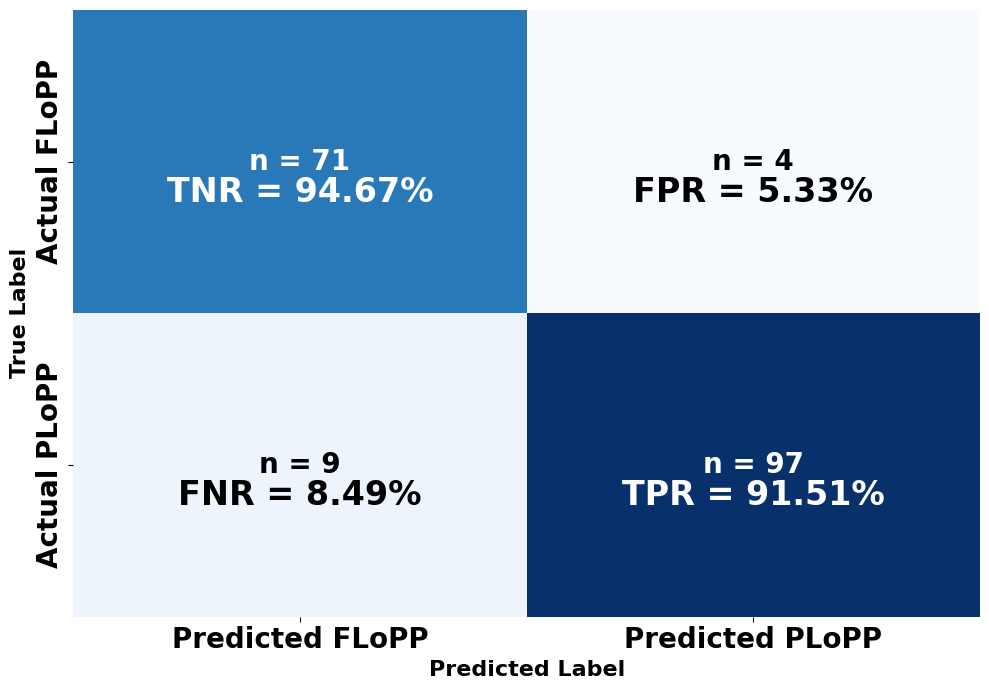

In [13]:
# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
tn, fp, fn, tp = cm.ravel()

# Calculate additional metrics
total_accuracy = (tp + tn) / (tp + tn + fp + fn)
tpr = tp / (tp + fn)
fpr = fp / (fp + tn)
tnr = tn / (tn + fp)
fnr = fn / (fn + tp)

print(f'Total number of false positives: {fp}')
print(f'Total number of false negatives: {fn}')


print(f'Total Accuracy: {total_accuracy:.2f}')
print(f'True Positive Rate: {tpr:.2f}')
print(f'False Positive Rate: {fpr:.2f}')
print(f'True Negative Rate: {tnr:.2f}')
print(f'False Negative Rate: {fnr:.2f}')

# Creating a DataFrame for Confusion Matrix for better visualization
confusion_df = pd.DataFrame(cm, index=['Actual FLoPP', 'Actual PLoPP'], columns=['Predicted FLoPP', 'Predicted PLoPP'])

# Plotting the confusion matrix heatmap
fig, ax = plt.subplots(figsize=(10, 7))
sns.heatmap(confusion_df, annot=False, fmt='d', cmap='Blues', cbar=False, ax=ax)  # Set annot=True to show numbers
#ax.set_title('Random Forest Confusion Matrix')
ax.set_xlabel('Predicted Label', fontsize=16, weight='bold')
ax.set_ylabel('True Label', fontsize=16, weight='bold')
ax.set_xticklabels(ax.get_xticklabels(), fontsize=20, weight='bold')
ax.set_yticklabels(ax.get_yticklabels(), fontsize=20, weight='bold')

# Annotate confusion matrix with TPR, FPR, etc.
for i in range(2):
    for j in range(2):
        color = 'white' if (i == 0 and j == 0) or (i == 1 and j == 1) else 'black'
        plt.text(j + 0.5, i + 0.5, f'n = {cm[i, j]}', ha='center', va='center', color=color, fontsize=20, weight='bold')

plt.text(0.5, 0.6, f'TNR = {tnr * 100:.2f}%', ha='center', va='center', fontsize=24, weight='bold', color='white')
plt.text(1.5, 0.6, f'FPR = {fpr * 100:.2f}%', ha='center', va='center', fontsize=24, weight='bold')
plt.text(.5, 1.6, f'FNR = {fnr * 100:.2f}%', ha='center', va='center', fontsize=24, weight='bold')
plt.text(1.5, 1.6, f'TPR = {tpr * 100:.2f}%', ha='center', va='center', fontsize=24, weight='bold', color='white')
plt.tight_layout()
#save this plot to a folder:
#plt.savefig('../../../../Manuscript/Figures/Figure 4 Confusion matrix and box and whisker/Figure4_confusion_matrix_March_2025.png')

plt.show()

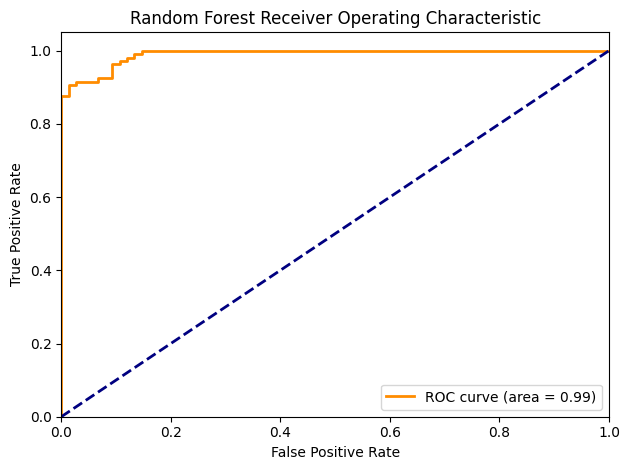

In [14]:
# ROC Curve
y_prob = pipeline.predict_proba(X_test)[:, 1]
fpr, tpr, thresholds = roc_curve(y_test, y_prob, pos_label='PLoPP')
roc_auc = auc(fpr, tpr)

fig, ax = plt.subplots()
ax.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:0.2f})')
ax.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
ax.set_xlim([0.0, 1.0])
ax.set_ylim([0.0, 1.05])
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('Random Forest Receiver Operating Characteristic')
ax.legend(loc="lower right")
plt.tight_layout()
#plt.savefig('../../../../Manuscript/Figures/Figure 4 Confusion matrix and box and whisker/Figure_ROC_curve_March_2025.png')

plt.show()

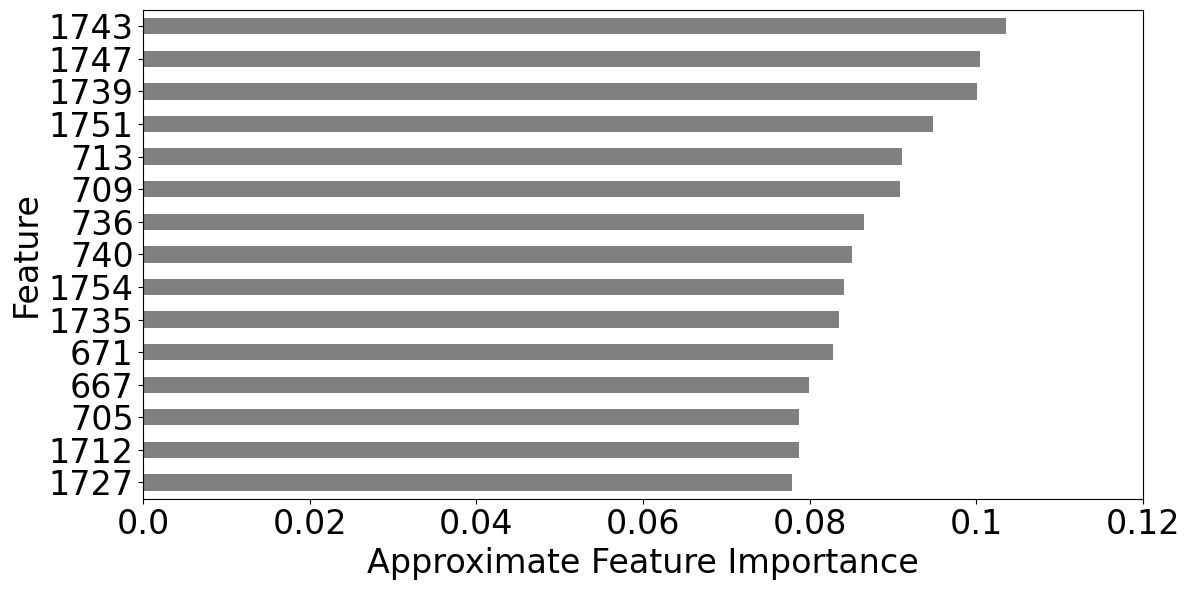

In [15]:
# Access the PCA and classifier from the pipeline
pca = pipeline.named_steps['pca']
classifier = pipeline.named_steps['classifier']

# Get the importance of the components from the classifier
component_importances = classifier.feature_importances_

# Get the original feature names and the PCA components
original_feature_names = X_train.columns
pca_components = pca.components_

# Calculate the approximate importance of the original features
approx_feature_importances = np.zeros(len(original_feature_names))

for i, component_importance in enumerate(component_importances):
    approx_feature_importances += component_importance * np.abs(pca_components[i])

# Create a series with the approximate importances
approx_importances_series = pd.Series(approx_feature_importances, index=original_feature_names)

# Sort and get the top 15 most important features
top_importances = approx_importances_series.sort_values(ascending=True)[-15:]

# Plot the feature importances
fig, ax = plt.subplots(figsize=(12, 6))
top_importances.plot(kind='barh', ax=ax, color='grey')

# Customize the plot with larger font sizes
ax.set_ylabel("Feature", fontsize=24)
ax.set_xlabel("Approximate Feature Importance", fontsize=24)
ax.set_xticks(ax.get_xticks())
ax.set_xticklabels(ax.get_xticks(), fontsize=24)
ax.set_yticklabels(top_importances.index, fontsize=24)
plt.tight_layout()
#plt.savefig('../../../../Manuscript/Figures/Figure 4 Confusion matrix and box and whisker/Figure_Estimated_Feature_Importance_March_2025.png')


plt.show()


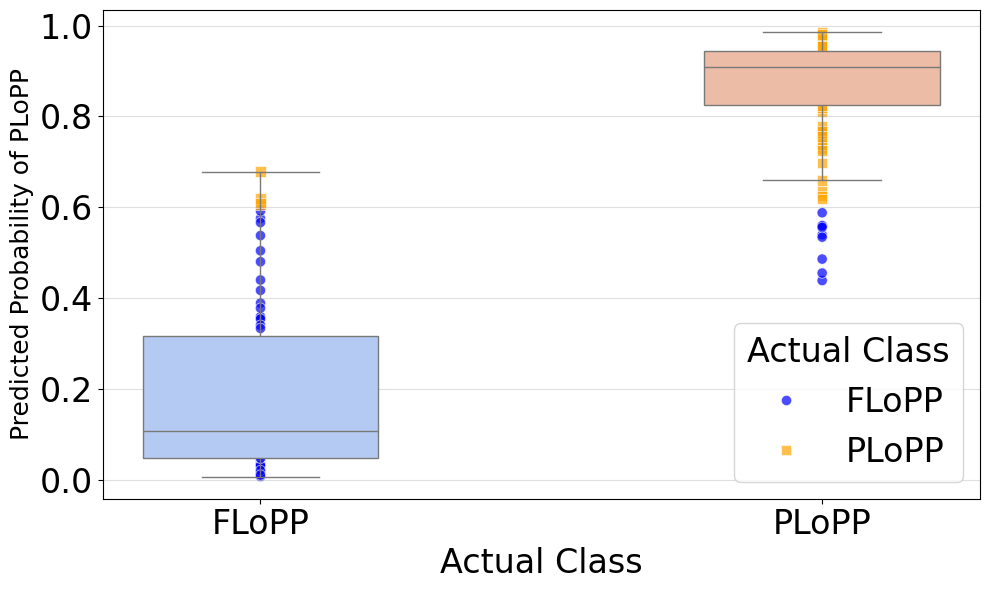

In [16]:
# Predicted Probabilities Plot
plot_data = pd.DataFrame({
    'Predicted Probability': y_prob,
    'Predicted Class': y_pred,
    'Actual Class': y_test
})

plot_data['Actual Class'] = pd.Categorical(plot_data['Actual Class'])
plot_data['Actual Class'] = plot_data['Actual Class'].cat.rename_categories({0: 'FLoPP', 1: 'PLoPP'})
plot_data['Predicted Class'] = pd.Categorical(plot_data['Predicted Class'])
plot_data['Predicted Class'] = plot_data['Predicted Class'].cat.rename_categories({0: 'FLoPP', 1: 'PLoPP'})

class_order = ['FLoPP', 'PLoPP']

plt.figure(figsize=(10, 6))

sns.boxplot(
    data=plot_data,
    x='Actual Class',
    y='Predicted Probability',
    hue='Actual Class',
    order=class_order,
    hue_order=class_order,
    palette='coolwarm',
    dodge=False,
    width=0.42,
    whis=1.5,
    fliersize=0,
    legend=False
)

sns.scatterplot(
    data=plot_data,
    x='Actual Class',
    y='Predicted Probability',
    hue='Predicted Class',
    style='Predicted Class',
    hue_order=class_order,
    style_order=class_order,
    palette={'FLoPP': 'blue', 'PLoPP': 'orange'},
    markers={'FLoPP': 'o', 'PLoPP': 's'},
    alpha=0.7,
    s=55
)

plt.ylabel('Predicted Probability of PLoPP', fontsize=18)
plt.xlabel('Actual Class', fontsize=24)
plt.xticks(fontsize=24)
plt.yticks(fontsize=24)
plt.grid(True, axis='y', alpha=0.4)

plt.legend(title='Actual Class', loc='lower right', fontsize=24, title_fontsize=24)
plt.tight_layout()
plt.show()


In [17]:
print("Overall Model Stats")

# Max, Min, and Mean values of the predicted probabilities, rounded to 2 decimal places
print(f"Max Predicted Probability: {plot_data['Predicted Probability'].max():.2f}")
print(f"Min Predicted Probability: {plot_data['Predicted Probability'].min():.2f}")
print(f"Mean Predicted Probability: {plot_data['Predicted Probability'].mean():.2f}")

print("----------")
print("PLoPP Stats")

# Stats for when Predicted Class = 'PLoPP', rounded to 2 decimal places
print(f"Max Predicted Probability: {plot_data[plot_data['Predicted Class'] == 'PLoPP']['Predicted Probability'].max():.2f}")
print(f"Min Predicted Probability: {plot_data[plot_data['Predicted Class'] == 'PLoPP']['Predicted Probability'].min():.2f}")
print(f"Mean Predicted Probability: {plot_data[plot_data['Predicted Class'] == 'PLoPP']['Predicted Probability'].mean():.2f}")

print("----------")
print("FLoPP Stats")

# Stats for when Predicted Class = 'FLoPP', rounded to 2 decimal places
print(f"Max Predicted Probability: {plot_data[plot_data['Predicted Class'] == 'FLoPP']['Predicted Probability'].max():.2f}")
print(f"Min Predicted Probability: {plot_data[plot_data['Predicted Class'] == 'FLoPP']['Predicted Probability'].min():.2f}")
print(f"Mean Predicted Probability: {plot_data[plot_data['Predicted Class'] == 'FLoPP']['Predicted Probability'].mean():.2f}")


Overall Model Stats
Max Predicted Probability: 0.99
Min Predicted Probability: 0.01
Mean Predicted Probability: 0.58
----------
PLoPP Stats
Max Predicted Probability: 0.99
Min Predicted Probability: 0.61
Mean Predicted Probability: 0.88
----------
FLoPP Stats
Max Predicted Probability: 0.59
Min Predicted Probability: 0.01
Mean Predicted Probability: 0.21


# Andrew Turner's Samples

In [18]:
# load data

def process_csv_files(directory):
    data_frames = []

    for filename in os.listdir(directory):
        # add logic if filename has 'samplekey' in title, skip
        if filename != 'SampleKey.csv' and filename != 'merged' and filename.endswith('.CSV'):
            file_path = os.path.join(directory, filename) 

            df = pd.read_csv(file_path, header=None, names=['Wavelength', 'Datavalue'])
            df_transposed = df.set_index('Wavelength').T
            df_transposed['Sample'] = filename

            data_frames.append(df_transposed)

    master_df = pd.concat(data_frames, axis=0).fillna(0)

    return master_df


directory = "../../Andrew Turner data"


validate_df = process_csv_files(directory)

# remove .csv from Sample column
validate_df['Sample'] = validate_df['Sample'].str.replace('.CSV', '')

sample_key = pd.read_csv("../../Andrew Turner data/SampleKey_correct_sector.csv")

print(validate_df.shape)
validate_df.head()

(39, 937)


Wavelength,397.280900,401.138000,404.995100,408.852200,412.709300,416.566400,420.423500,424.280500,428.137700,431.994800,...,3972.809000,3976.666000,3980.523000,3984.380000,3988.237000,3992.094000,3995.951000,3999.809000,4003.666000,Sample
Datavalue,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,94.400630,94.343530,94.353070,94.387180,94.364510,94.335640,94.381750,94.442980,0.000000,MP_ID_1
Datavalue,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,94.199910,94.189160,94.233110,94.283070,94.275090,94.252850,94.240340,94.290470,0.000000,MP_ID_10
Datavalue,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,103.864900,103.844100,103.944900,104.007900,103.982900,103.952600,103.943900,104.008200,0.000000,MP_ID_11
Datavalue,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,111.486400,111.494400,111.495700,111.497000,111.402200,111.174500,111.181400,111.373800,0.000000,MP_ID_12
Datavalue,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,90.064240,90.082480,90.094150,90.051620,89.984180,89.996600,90.113910,90.201220,0.000000,MP_ID_13


In [19]:
merged_df = pd.merge(validate_df, sample_key, left_on='Sample', right_on = "Mira's ID", how='left')

merged_df.columns = [int(col) if col not in ['Sample', "Mira's ID", 'Paint or non-paint','zoie_sector'] else col for col in merged_df.columns]

# rename 'Paint or non-Paint' to 'observed'
merged_df.rename(columns={"Paint or non-paint": "observed"}, inplace=True)
merged_df.drop(["Mira's ID"], axis=1, inplace=True) 

merged_df['observed'] = merged_df['observed'].map({'Non-paint': 'FLOPP', 'Paint': 'PLOPP'})

#merged_df.to_csv('../../Andrew Turner data/merged_validation_data.csv')

# change the name of observed to PLoPP if PLOPP and FLoPP if FLOPP
merged_df['observed'] = merged_df['observed'].map({'PLOPP': 'PLoPP', 'FLOPP': 'FLoPP'})

# 11.11.24 - drop when Sample = MP_ID_5 from sample 
merged_df = merged_df.drop(merged_df[merged_df['Sample'] == 'MP_ID_5'].index)

andrew_turner_df = merged_df
print(merged_df.shape)
merged_df.head()

(38, 939)


,397,401,404,408,412,416,420,424,428,431,...,3980,3984,3988,3992,3995,3999,4003,Sample,observed,zoie_sector
0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,94.353070,94.387180,94.364510,94.335640,94.381750,94.442980,0.000000,MP_ID_1,PLoPP,Road marking
1,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,94.233110,94.283070,94.275090,94.252850,94.240340,94.290470,0.000000,MP_ID_10,FLoPP,NaN
2,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,103.944900,104.007900,103.982900,103.952600,103.943900,104.008200,0.000000,MP_ID_11,PLoPP,Road marking
3,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,111.495700,111.497000,111.402200,111.174500,111.181400,111.373800,0.000000,MP_ID_12,FLoPP,Marine
4,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,90.094150,90.051620,89.984180,89.996600,90.113910,90.201220,0.000000,MP_ID_13,PLoPP,General Industrial


In [20]:
# Citadel Data Processing

#new_directory = "../../../../Citadel spectra samples ZD/CSV files"
new_directory = "../data/citadel/"

def process_csv_files(directory):
    data_frames = []

    for filename in os.listdir(directory):
        # add logic if filename has 'samplekey' in title, skip
        if filename != 'SampleKey.csv' and filename != 'merged' and (filename.endswith('.csv') or filename.endswith('.CSV')):
            file_path = os.path.join(directory, filename) 

            df = pd.read_csv(file_path, header=None, names=['Wavelength', 'Datavalue'])
            df_transposed = df.set_index('Wavelength').T
            df_transposed['Sample'] = filename

            data_frames.append(df_transposed)

    master_df = pd.concat(data_frames, axis=0).fillna(0)

    return master_df
new_test = process_csv_files(new_directory)

#new_test.columns = [int(col) if col not in ['Sample', 'Target', 'Wavelength'] else col for col in new_test.columns]

# new_test.drop(columns=['Wavelength'], inplace=True)

# reset the axis, and drop the index

new_test.reset_index(drop=True, inplace=True)


print(new_test.shape)



cols_to_keep = [col for col in merged_df.columns if col not in ['observed', 'zoie_sector']]


# Ensure new_test has the same number of columns as cols_to_keep
if len(new_test.columns) == len(cols_to_keep):
    # Assign the column names from cols_to_keep
    new_test.columns = cols_to_keep
else:
    raise ValueError(f"Number of columns in 'new_test' ({len(new_test.columns)}) does not match 'cols_to_keep' ({len(cols_to_keep)}).")



# add observed and zoie_sector

# remove .csv from end of 'Sample' column
new_test['Sample'] = new_test['Sample'].str.replace('.csv', '')

new_test.head()


(49, 937)


,397,401,404,408,412,416,420,424,428,431,...,3972,3976,3980,3984,3988,3992,3995,3999,4003,Sample
0,0.000000,0.005151,0.022414,0.028511,0.036840,0.029070,0.032857,0.025132,0.020667,0.032295,...,0.007581,0.007429,0.007432,0.007444,0.007412,0.007718,0.007793,0.007703,0.000000,HA.T1.M2.N.CSV
1,0.000000,0.033673,0.033782,0.058037,0.031785,0.037973,0.007846,0.010979,0.008492,0.017785,...,-0.029320,-0.029284,-0.028988,-0.029035,-0.028914,-0.029175,-0.029197,-0.029070,0.000000,HA.T1.M2.S
2,0.000000,0.028998,0.072479,0.062337,0.058387,0.052680,0.007628,0.031624,0.037149,0.025380,...,-0.000036,-0.000008,-0.000036,-0.000108,-0.000343,-0.000426,-0.000318,-0.000358,0.000000,HA.T1.R1.N
3,0.000000,0.004127,-0.027324,-0.034116,-0.014517,0.009069,-0.007481,-0.015698,-0.011484,-0.013285,...,-0.033424,-0.033525,-0.033353,-0.033495,-0.033551,-0.033390,-0.033328,-0.033416,0.000000,HA.T1.R1.S.CSV
4,0.000000,0.058569,0.059341,0.103010,0.104995,0.077643,0.071592,0.067580,0.062502,0.062201,...,0.008445,0.008532,0.008462,0.008397,0.008429,0.008433,0.008629,0.008790,0.000000,HA.T1.R2.S


In [21]:
sample_key = pd.read_excel("../data/citadel/2024.11.27_Citadel_sampleKey_ZoieForJake.xlsx")

sample_key = sample_key[['Sample name', 'Paint or non-paint', 'Sector']]

# rename Paint or non-paint to observed
sample_key.rename(columns={"Paint or non-paint": "observed", "Sector": "zoie_sector", "Sample name": "Sample"}, inplace=True)

# rename when observed is non-paint to FLoPP and paint to PLoPP
sample_key['observed'] = sample_key['observed'].map({'Non-paint': 'FLoPP', 'Paint': 'PLoPP'})
sample_key.head()
temp_merge = pd.merge(new_test, sample_key, left_on='Sample', right_on = "Sample", how='left')

print(temp_merge.shape)
temp_merge.head()

(49, 939)


,397,401,404,408,412,416,420,424,428,431,...,3980,3984,3988,3992,3995,3999,4003,Sample,observed,zoie_sector
0,0.000000,0.005151,0.022414,0.028511,0.036840,0.029070,0.032857,0.025132,0.020667,0.032295,...,0.007432,0.007444,0.007412,0.007718,0.007793,0.007703,0.000000,HA.T1.M2.N.CSV,NaN,NaN
1,0.000000,0.033673,0.033782,0.058037,0.031785,0.037973,0.007846,0.010979,0.008492,0.017785,...,-0.028988,-0.029035,-0.028914,-0.029175,-0.029197,-0.029070,0.000000,HA.T1.M2.S,PLoPP,Road marking
2,0.000000,0.028998,0.072479,0.062337,0.058387,0.052680,0.007628,0.031624,0.037149,0.025380,...,-0.000036,-0.000108,-0.000343,-0.000426,-0.000318,-0.000358,0.000000,HA.T1.R1.N,PLoPP,Road marking
3,0.000000,0.004127,-0.027324,-0.034116,-0.014517,0.009069,-0.007481,-0.015698,-0.011484,-0.013285,...,-0.033353,-0.033495,-0.033551,-0.033390,-0.033328,-0.033416,0.000000,HA.T1.R1.S.CSV,NaN,NaN
4,0.000000,0.058569,0.059341,0.103010,0.104995,0.077643,0.071592,0.067580,0.062502,0.062201,...,0.008462,0.008397,0.008429,0.008433,0.008629,0.008790,0.000000,HA.T1.R2.S,PLoPP,Road marking


In [22]:
total_merged = pd.concat([merged_df, temp_merge], axis=0)
# rename 'Industrial Wood' in zoie_sector to 'Wood'
total_merged['zoie_sector'] = total_merged['zoie_sector'].replace('Industrial Wood', 'Wood')
total_merged['zoie_sector'] = total_merged['zoie_sector'].replace('Road marking', 'Road Marking')
total_merged.shape



(87, 939)

In [23]:
total_merged.zoie_sector.value_counts()


zoie_sector
Road Marking          40
Marine                10
Architectural          8
General Industrial     7
Wood                   1
Name: count, dtype: int64

In [24]:
total_merged.head()

,397,401,404,408,412,416,420,424,428,431,...,3980,3984,3988,3992,3995,3999,4003,Sample,observed,zoie_sector
0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,94.353070,94.387180,94.364510,94.335640,94.381750,94.442980,0.000000,MP_ID_1,PLoPP,Road Marking
1,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,94.233110,94.283070,94.275090,94.252850,94.240340,94.290470,0.000000,MP_ID_10,FLoPP,NaN
2,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,103.944900,104.007900,103.982900,103.952600,103.943900,104.008200,0.000000,MP_ID_11,PLoPP,Road Marking
3,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,111.495700,111.497000,111.402200,111.174500,111.181400,111.373800,0.000000,MP_ID_12,FLoPP,Marine
4,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,90.094150,90.051620,89.984180,89.996600,90.113910,90.201220,0.000000,MP_ID_13,PLoPP,General Industrial


In [25]:
total_merged.observed.value_counts()

print(total_merged.shape)

(87, 939)


In [26]:
# drop any rows where observed is NaN
total_merged = total_merged.dropna(subset=['observed'])

print(total_merged.shape)

(85, 939)


In [27]:
# Ensure 'Group' is not part of the input data if it exists
if 'Group' in total_merged.columns:
    X_validation = total_merged.drop(columns=['Group'])
else:
    X_validation = total_merged

# Use the pipeline to make predictions on the external validation data
X_validation_features = X_validation.drop(columns=['Sample', 'observed', 'zoie_sector'], errors='ignore') 
y_validation_pred = pipeline.predict(X_validation_features)

# Convert predictions to a pandas Series for mapping
y_validation_pred = pd.Series(y_validation_pred)

# If you want probabilities instead of just predictions
y_validation_proba = pipeline.predict_proba(X_validation_features)

# Optional: Evaluate the predictions if you have the true labels in `total_merged`
if 'observed' in total_merged.columns:
    y_validation_true = total_merged['observed']

    # Map labels to numeric values
    label_mapping = {'PLoPP': 1, 'FLoPP': 0}
    y_validation_true = y_validation_true.map(label_mapping)
    y_validation_pred = y_validation_pred.map(label_mapping)

    # Handle missing values
    y_validation_true = y_validation_true.fillna(-1)
    y_validation_pred = y_validation_pred.fillna(-1)

    # Check the transformation
    print("Unique values in y_validation_true:", y_validation_true.unique())
    print("Unique values in y_validation_pred:", y_validation_pred.unique())

    # Calculate metrics
    accuracy = accuracy_score(y_validation_true, y_validation_pred)
    precision = precision_score(y_validation_true, y_validation_pred, average='weighted', zero_division=0)
    recall = recall_score(y_validation_true, y_validation_pred, average='weighted', zero_division=0)
    f1 = f1_score(y_validation_true, y_validation_pred, average='weighted', zero_division=0)

    print(f"Validation Data Evaluation:")
    print("Accuracy:", accuracy)
    print("Precision (weighted):", precision)
    print("Recall (weighted):", recall)
    print("F1 Score (weighted):", f1)

    # Confusion matrix and additional metrics
    cm = confusion_matrix(y_validation_true, y_validation_pred)
    print("Confusion Matrix:\n", cm)

    if cm.shape == (2, 2):  # Binary classification
        tn, fp, fn, tp = cm.ravel()

        total_accuracy = (tp + tn) / (tp + tn + fp + fn)
        tpr = tp / (tp + fn)
        fpr = fp / (fp + tn)
        tnr = tn / (tn + fp)
        fnr = fn / (fn + tp)

        print(f'Total Accuracy: {total_accuracy:.2f}')
        print(f'True Positive Rate: {tpr:.2f}')
        print(f'False Positive Rate: {fpr:.2f}')
        print(f'True Negative Rate: {tnr:.2f}')
        print(f'False Negative Rate: {fnr:.2f}')


Unique values in y_validation_true: [1 0]
Unique values in y_validation_pred: [0 1]
Validation Data Evaluation:
Accuracy: 0.5529411764705883
Precision (weighted): 0.7938013915243516
Recall (weighted): 0.5529411764705883
F1 Score (weighted): 0.5764772125066242
Confusion Matrix:
 [[18  2]
 [36 29]]
Total Accuracy: 0.55
True Positive Rate: 0.45
False Positive Rate: 0.10
True Negative Rate: 0.90
False Negative Rate: 0.55


In [28]:
total_merged['prediction_group'] = y_validation_pred
total_merged.head()

,397,401,404,408,412,416,420,424,428,431,...,3984,3988,3992,3995,3999,4003,Sample,observed,zoie_sector,prediction_group
0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,94.387180,94.364510,94.335640,94.381750,94.442980,0.000000,MP_ID_1,PLoPP,Road Marking,0
1,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,94.283070,94.275090,94.252850,94.240340,94.290470,0.000000,MP_ID_10,FLoPP,NaN,0
2,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,104.007900,103.982900,103.952600,103.943900,104.008200,0.000000,MP_ID_11,PLoPP,Road Marking,1
3,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,111.497000,111.402200,111.174500,111.181400,111.373800,0.000000,MP_ID_12,FLoPP,Marine,1
4,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,90.051620,89.984180,89.996600,90.113910,90.201220,0.000000,MP_ID_13,PLoPP,General Industrial,1


In [29]:
total_merged[['Sample', 'observed', 'zoie_sector', 'prediction_group']].to_csv('environmental_validation_results.csv', index=False)


#  Paint by sector

Purpose of this section is to determine if the model can differentiate between different sectors. 

In [30]:
train_df = pd.read_csv("../../data/output/merged_df.csv")

# drop Group column
train_df.drop(columns=['Group'], inplace=True)

train_df = train_df[train_df['Target'] == 'PLoPP']
print(train_df.shape)

train_df.head()

(263, 939)


,Unnamed: 0,397,401,404,408,412,416,420,424,428,...,3976,3980,3984,3988,3992,3995,3999,4003,Sample,Target
186,186,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,91.817920,91.799890,91.768400,91.759260,91.803400,91.885330,91.895230,0.000000,54c.CSV,PLoPP
187,187,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,97.245870,97.219830,97.283520,97.345570,97.343240,97.352390,97.383830,0.000000,23a.CSV,PLoPP
188,188,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,91.535050,91.539890,91.538020,91.560490,91.593530,91.580960,91.587860,0.000000,74a.CSV,PLoPP
189,189,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,92.119210,92.109000,92.050710,92.068950,92.132290,92.172480,92.242130,0.000000,78b.CSV,PLoPP
190,190,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,94.578730,94.567590,94.558040,94.586940,94.629390,94.671810,94.684270,0.000000,9a.CSV,PLoPP


In [31]:
add_sector_df = pd.read_csv("../../data/merged_df_sector_color.csv")

print(add_sector_df.shape)

cols_to_kepp = ['CSVName', 'Sample', 'Sample_Number', 'Color', 'Sector']
add_sector_df = add_sector_df[cols_to_kepp]
add_sector_df.head()

(263, 869)


,CSVName,Sample,Sample_Number,Color,Sector
0,54c.CSV,54c,54,Green,Automotive
1,23a.CSV,23a,23,Black,General Industrial
2,74a.CSV,74a,74,Green,Architectural
3,78b.CSV,78b,78,Yellow,General Industrial
4,9a.CSV,9a,9,Yellow,Architectural


In [32]:
add_sector_df.Sector.value_counts()

Sector
Architectural         85
Automotive            65
General Industrial    45
Consumer              29
Marine                20
Road Marking          10
Industrial Wood        9
Name: count, dtype: int64

In [33]:
train_with_sectors = pd.merge(train_df, add_sector_df, left_on='Sample', right_on='CSVName', how='left')

print(train_with_sectors.shape)

train_with_sectors.head()

(263, 944)


,Unnamed: 0,397,401,404,408,412,416,420,424,428,...,3995,3999,4003,Sample_x,Target,CSVName,Sample_y,Sample_Number,Color,Sector
0,186,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,91.885330,91.895230,0.000000,54c.CSV,PLoPP,54c.CSV,54c,54,Green,Automotive
1,187,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,97.352390,97.383830,0.000000,23a.CSV,PLoPP,23a.CSV,23a,23,Black,General Industrial
2,188,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,91.580960,91.587860,0.000000,74a.CSV,PLoPP,74a.CSV,74a,74,Green,Architectural
3,189,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,92.172480,92.242130,0.000000,78b.CSV,PLoPP,78b.CSV,78b,78,Yellow,General Industrial
4,190,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,94.671810,94.684270,0.000000,9a.CSV,PLoPP,9a.CSV,9a,9,Yellow,Architectural


In [34]:
train_with_sectors.Sector.value_counts()

Sector
Architectural         85
Automotive            65
General Industrial    45
Consumer              29
Marine                20
Road Marking          10
Industrial Wood        9
Name: count, dtype: int64

In [35]:
train_with_sectors.shape

(263, 944)

In [36]:
train_with_sectors.head()

,Unnamed: 0,397,401,404,408,412,416,420,424,428,...,3995,3999,4003,Sample_x,Target,CSVName,Sample_y,Sample_Number,Color,Sector
0,186,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,91.885330,91.895230,0.000000,54c.CSV,PLoPP,54c.CSV,54c,54,Green,Automotive
1,187,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,97.352390,97.383830,0.000000,23a.CSV,PLoPP,23a.CSV,23a,23,Black,General Industrial
2,188,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,91.580960,91.587860,0.000000,74a.CSV,PLoPP,74a.CSV,74a,74,Green,Architectural
3,189,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,92.172480,92.242130,0.000000,78b.CSV,PLoPP,78b.CSV,78b,78,Yellow,General Industrial
4,190,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,94.671810,94.684270,0.000000,9a.CSV,PLoPP,9a.CSV,9a,9,Yellow,Architectural


In [37]:
# rename anytome train_with_sectors is Industrial Wood to just Wood

# drop column 'Unnamed: 0' column if it exists
if 'Unnamed: 0' in train_with_sectors.columns:
    train_with_sectors = train_with_sectors.drop(columns=['Unnamed: 0'])

train_with_sectors['Sector'] = train_with_sectors['Sector'].replace('Industrial Wood', 'Wood')

# Prepare features and labels
X = train_with_sectors.drop(columns=['Sector', 'Target', 'Sample_x', 'Sample_y', 'Sample_Number', 'Color', 'CSVName'])  # Drop unnecessary columns
y = train_with_sectors['Sector']

# Split the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Define the pipeline
pipeline = Pipeline([
    ('snv', SNVTransformer(use_scaling=True)),                # Apply SNV transformation
    ('derivative', DerivativeTransformer(deriv=1)),           # Apply derivative transformation
    ('pca', PCA(n_components=0.95)),                          # Apply PCA to retain 95% variance
    ('classifier', RandomForestClassifier(random_state=42))   # A RandomForest model
])



# Train the pipeline
pipeline.fit(X_train, y_train)

# Predictions and evaluation
y_pred = pipeline.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# Optionally, analyze the PCA component contributions as in your previous code
pca = pipeline.named_steps['pca']
cumulative_variance = np.cumsum(pca.explained_variance_ratio_)
n_components_95 = np.argmax(cumulative_variance >= 0.95) + 1
print(f"Number of components that account for 95% of the variance: {n_components_95}")


Accuracy: 0.7975

Classification Report:
                    precision    recall  f1-score   support

     Architectural       0.68      0.92      0.78        25
        Automotive       1.00      1.00      1.00        18
          Consumer       1.00      0.82      0.90        11
General Industrial       0.80      0.80      0.80        15
            Marine       0.00      0.00      0.00         5
      Road Marking       0.00      0.00      0.00         3
              Wood       1.00      0.50      0.67         2

          accuracy                           0.80        79
         macro avg       0.64      0.58      0.59        79
      weighted avg       0.76      0.80      0.77        79

Number of components that account for 95% of the variance: 15


c:\flexgen\repos\projects\PLOPP-analysis\analysis\src\venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\flexgen\repos\projects\PLOPP-analysis\analysis\src\venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\flexgen\repos\projects\PLOPP-analysis\analysis\src\venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _

### Supplemental Figure 3 



Sector: Automotive
Accuracy: 0.9747
Classification Report:
              precision    recall  f1-score   support

           0       0.97      1.00      0.98        61
           1       1.00      0.89      0.94        18

    accuracy                           0.97        79
   macro avg       0.98      0.94      0.96        79
weighted avg       0.98      0.97      0.97        79

Total number of false positives: 0
Total number of false negatives: 2
Total Accuracy: 0.97
True Positive Rate: 0.89
False Positive Rate: 0.00
True Negative Rate: 1.00
False Negative Rate: 0.11
contextual information: Automotive


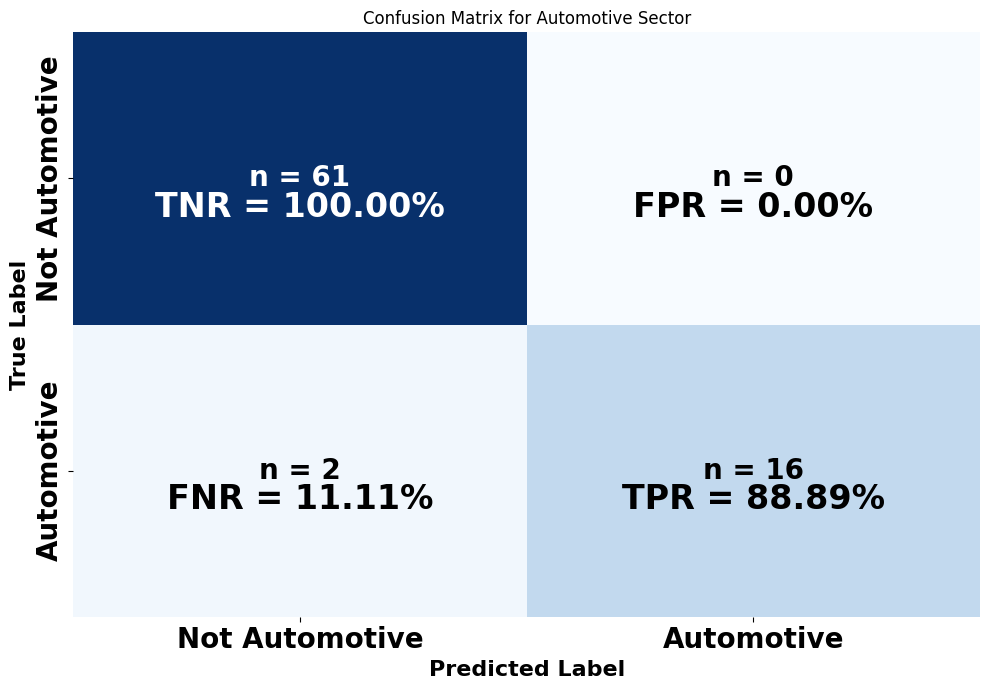


Sector: General Industrial
Accuracy: 0.9114
Classification Report:
              precision    recall  f1-score   support

           0       0.91      0.98      0.95        64
           1       0.90      0.60      0.72        15

    accuracy                           0.91        79
   macro avg       0.91      0.79      0.83        79
weighted avg       0.91      0.91      0.90        79

Total number of false positives: 1
Total number of false negatives: 6
Total Accuracy: 0.91
True Positive Rate: 0.60
False Positive Rate: 0.02
True Negative Rate: 0.98
False Negative Rate: 0.40
contextual information: General Industrial


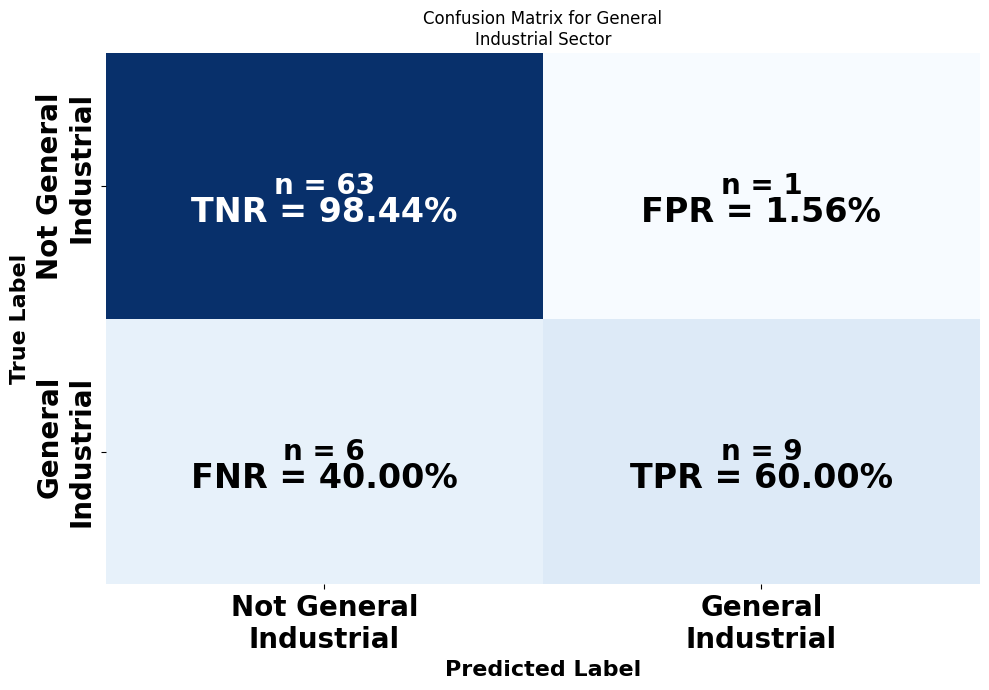


Sector: Architectural
Accuracy: 0.8861
Classification Report:
              precision    recall  f1-score   support

           0       0.91      0.93      0.92        54
           1       0.83      0.80      0.82        25

    accuracy                           0.89        79
   macro avg       0.87      0.86      0.87        79
weighted avg       0.89      0.89      0.89        79

Total number of false positives: 4
Total number of false negatives: 5
Total Accuracy: 0.89
True Positive Rate: 0.80
False Positive Rate: 0.07
True Negative Rate: 0.93
False Negative Rate: 0.20
contextual information: Architectural


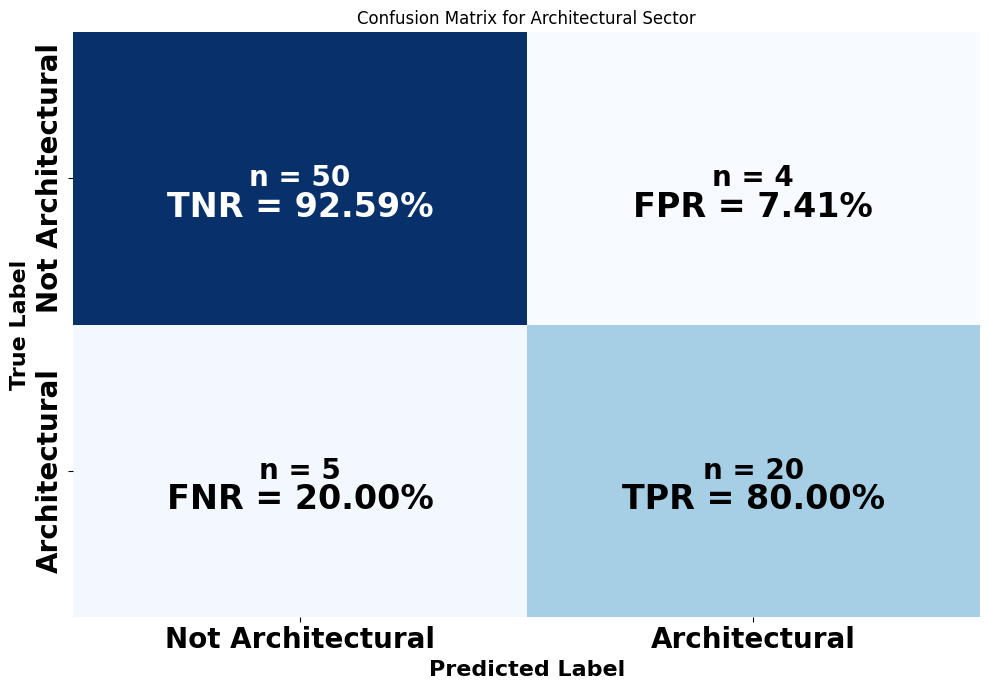


Sector: Road Marking
Accuracy: 0.9620
Classification Report:
              precision    recall  f1-score   support

           0       0.96      1.00      0.98        76
           1       0.00      0.00      0.00         3

    accuracy                           0.96        79
   macro avg       0.48      0.50      0.49        79
weighted avg       0.93      0.96      0.94        79

Total number of false positives: 0
Total number of false negatives: 3
Total Accuracy: 0.96
True Positive Rate: 0.00
False Positive Rate: 0.00
True Negative Rate: 1.00
False Negative Rate: 1.00
contextual information: Road Marking


c:\flexgen\repos\projects\PLOPP-analysis\analysis\src\venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\flexgen\repos\projects\PLOPP-analysis\analysis\src\venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\flexgen\repos\projects\PLOPP-analysis\analysis\src\venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _

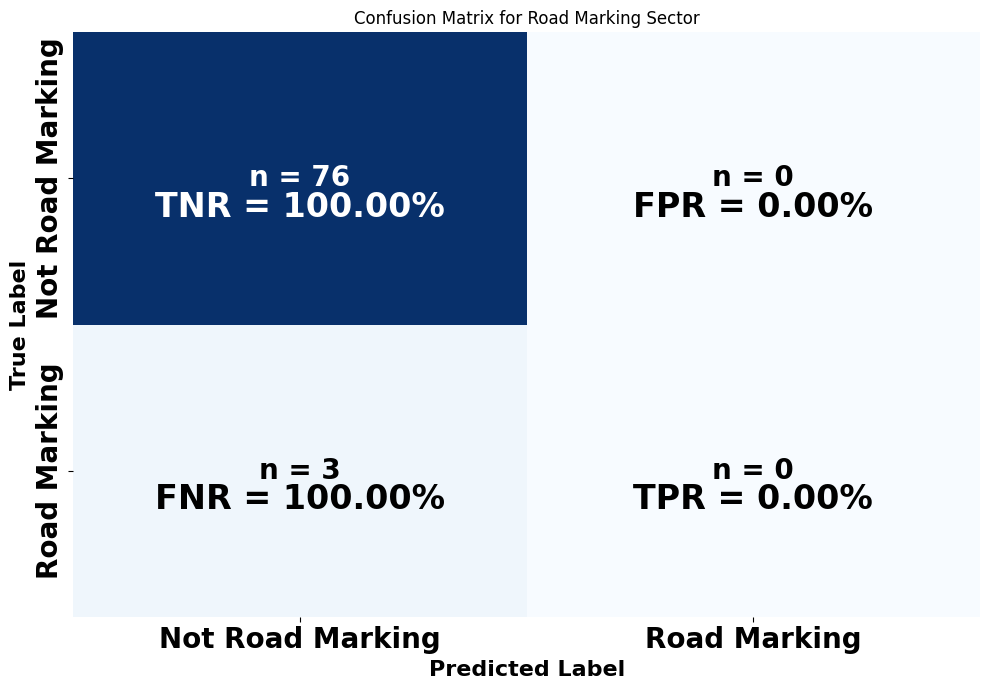


Sector: Consumer
Accuracy: 0.9367
Classification Report:
              precision    recall  f1-score   support

           0       0.93      1.00      0.96        68
           1       1.00      0.55      0.71        11

    accuracy                           0.94        79
   macro avg       0.97      0.77      0.84        79
weighted avg       0.94      0.94      0.93        79

Total number of false positives: 0
Total number of false negatives: 5
Total Accuracy: 0.94
True Positive Rate: 0.55
False Positive Rate: 0.00
True Negative Rate: 1.00
False Negative Rate: 0.45
contextual information: Consumer


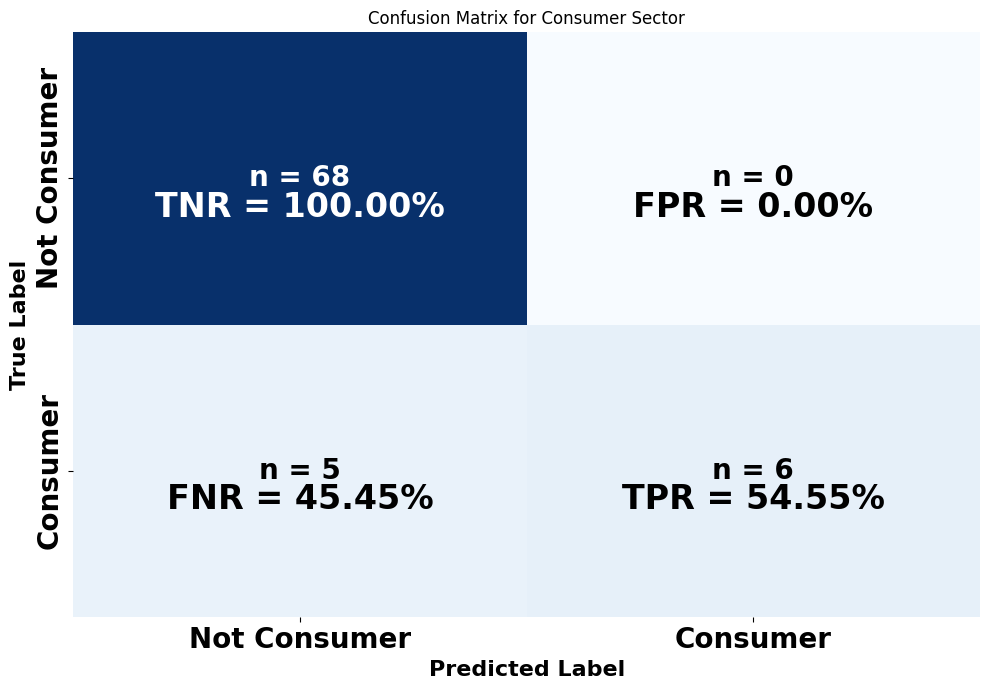


Sector: Wood
Accuracy: 0.9873
Classification Report:
              precision    recall  f1-score   support

           0       0.99      1.00      0.99        77
           1       1.00      0.50      0.67         2

    accuracy                           0.99        79
   macro avg       0.99      0.75      0.83        79
weighted avg       0.99      0.99      0.99        79

Total number of false positives: 0
Total number of false negatives: 1
Total Accuracy: 0.99
True Positive Rate: 0.50
False Positive Rate: 0.00
True Negative Rate: 1.00
False Negative Rate: 0.50
contextual information: Wood


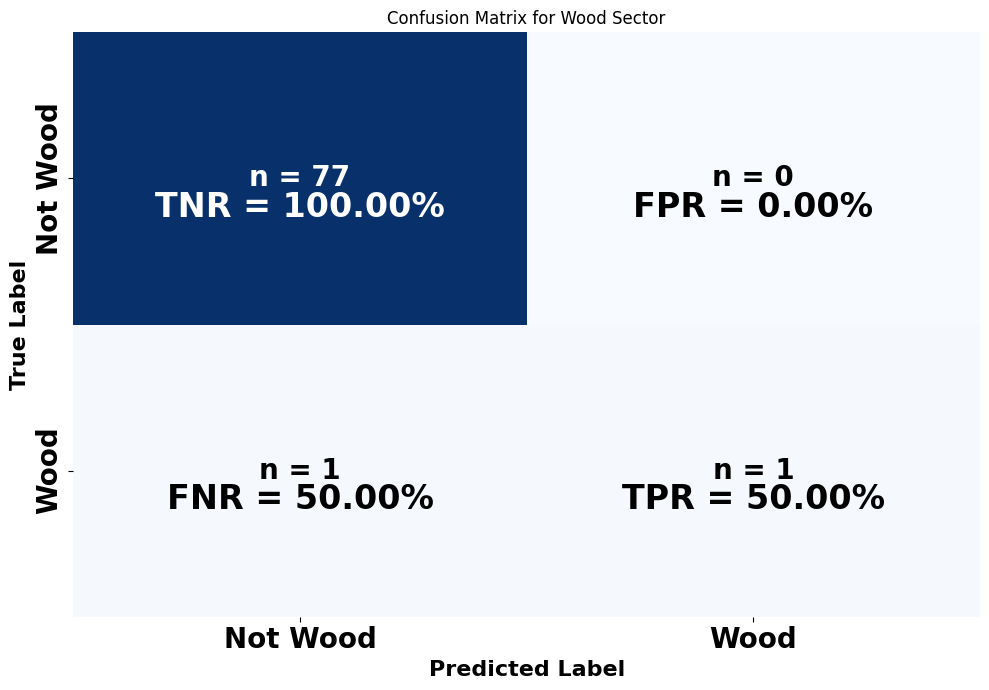


Sector: Marine
Accuracy: 0.9241
Classification Report:
              precision    recall  f1-score   support

           0       0.94      0.99      0.96        74
           1       0.00      0.00      0.00         5

    accuracy                           0.92        79
   macro avg       0.47      0.49      0.48        79
weighted avg       0.88      0.92      0.90        79

Total number of false positives: 1
Total number of false negatives: 5
Total Accuracy: 0.92
True Positive Rate: 0.00
False Positive Rate: 0.01
True Negative Rate: 0.99
False Negative Rate: 1.00
contextual information: Marine


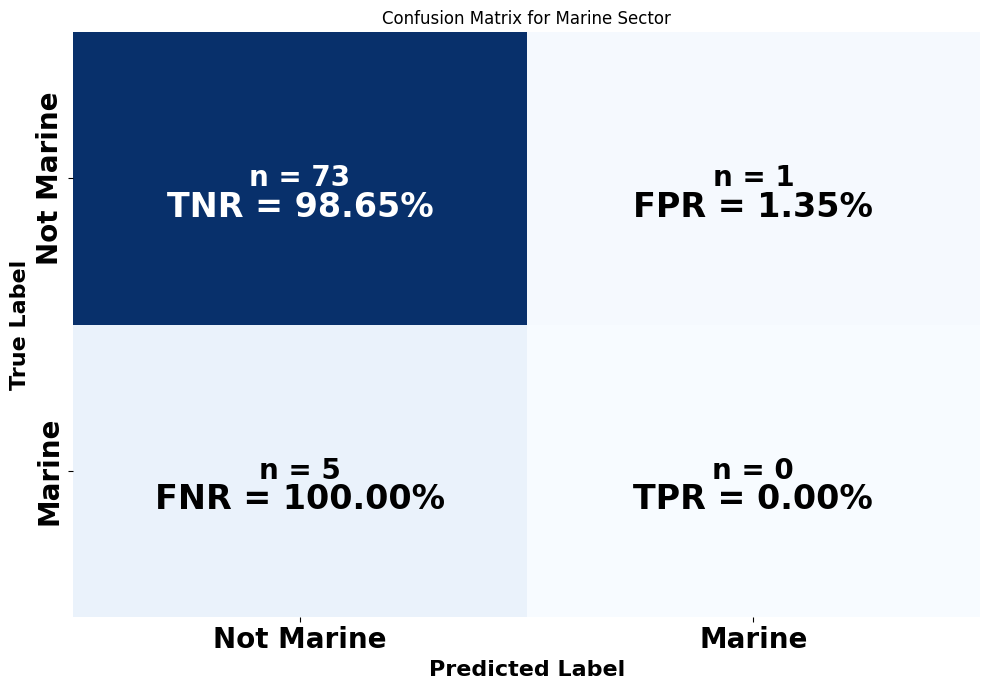

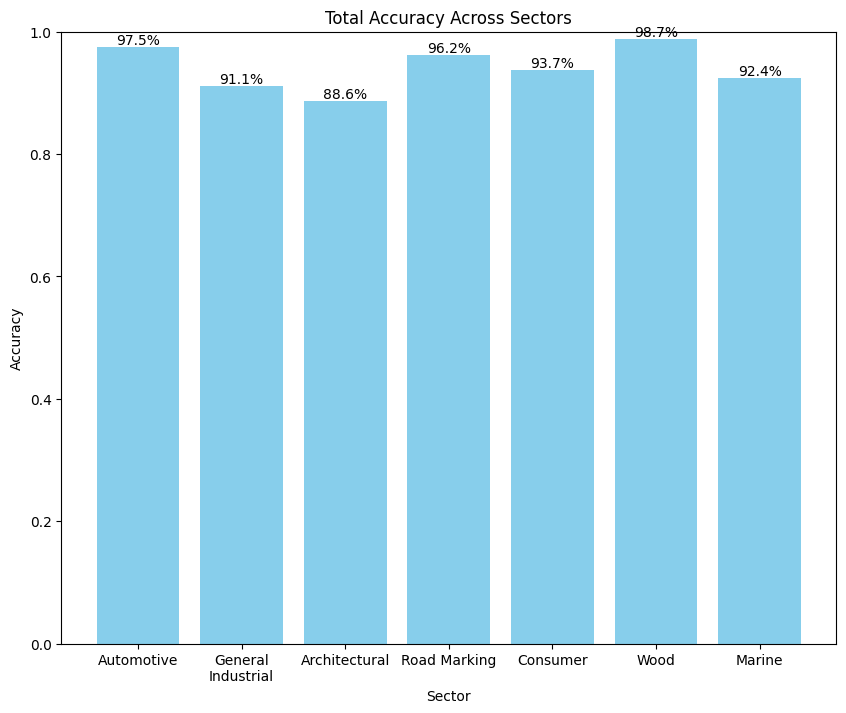


Total Accuracy across all sectors: 0.9403


In [38]:
# Define a function to prepare binary labels for a specific sector
def prepare_binary_labels(data, target_sector):
    data['SectorBinary'] = (data['Sector'] == target_sector).astype(int)
    return data

# Define a function to train and evaluate a model for each sector
def train_sector_model(data, target_sector):
    data = prepare_binary_labels(data, target_sector)

    X = data.drop(columns=['Unnamed: 0', 'Sector', 'Target', 'Sample_x', 'Sample_y', 'Sample_Number', 'Color', 'CSVName', 'SectorBinary'], errors='ignore')
    X.columns = X.columns.astype(str)
    y = data['SectorBinary']

    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

    pipeline = Pipeline([
        ('snv', SNVTransformer(use_scaling=True)),
        ('derivative', DerivativeTransformer(deriv=1)),
        ('pca', PCA(n_components=0.95)),
        ('classifier', RandomForestClassifier(random_state=42))
    ])

    pipeline.fit(X_train, y_train)
    y_pred = pipeline.predict(X_test)

    accuracy = accuracy_score(y_test, y_pred)
    print(f"\nSector: {target_sector}")
    print(f"Accuracy: {accuracy:.4f}")
    print("Classification Report:")
    print(classification_report(y_test, y_pred))

    cm = confusion_matrix(y_test, y_pred)
    tn, fp, fn, tp = cm.ravel()

    total_accuracy = (tp + tn) / (tp + tn + fp + fn)
    tpr = tp / (tp + fn)
    fpr = fp / (fp + tn)
    tnr = tn / (tn + fp)
    fnr = fn / (fn + tp)

    print(f'Total number of false positives: {fp}')
    print(f'Total number of false negatives: {fn}')
    print(f'Total Accuracy: {total_accuracy:.2f}')
    print(f'True Positive Rate: {tpr:.2f}')
    print(f'False Positive Rate: {fpr:.2f}')
    print(f'True Negative Rate: {tnr:.2f}')
    print(f'False Negative Rate: {fnr:.2f}')
    print(f"contextual information: {target_sector}")

    # Wrap "General Industrial" label with line break if needed
    display_sector = target_sector.replace("General Industrial", "General\nIndustrial")
    not_display_sector = f"Not {target_sector}".replace("General Industrial", "General\nIndustrial")

    fig, ax = plt.subplots(figsize=(10, 7))
    sns.heatmap(cm, annot=False, fmt='d', cmap='Blues', cbar=False,
                xticklabels=[not_display_sector, display_sector],
                yticklabels=[not_display_sector, display_sector],
                ax=ax)
    ax.set_xlabel('Predicted Label', fontsize=16, weight='bold')
    ax.set_ylabel('True Label', fontsize=16, weight='bold')
    ax.set_xticklabels(ax.get_xticklabels(), fontsize=20, weight='bold')
    ax.set_yticklabels(ax.get_yticklabels(), fontsize=20, weight='bold')

    for i in range(2):
        for j in range(2):
            color = 'white' if (i == 0 and j == 0) else 'black'
            plt.text(j + 0.5, i + 0.5, f'n = {cm[i, j]}', ha='center', va='center', color=color, fontsize=20, weight='bold')

    plt.text(0.5, 0.6, f'TNR = {tnr * 100:.2f}%', ha='center', va='center', fontsize=24, weight='bold', color='white')
    plt.text(1.5, 0.6, f'FPR = {fpr * 100:.2f}%', ha='center', va='center', fontsize=24, weight='bold')
    plt.text(.5, 1.6, f'FNR = {fnr * 100:.2f}%', ha='center', va='center', fontsize=24, weight='bold')
    plt.text(1.5, 1.6, f'TPR = {tpr * 100:.2f}%', ha='center', va='center', fontsize=24, weight='bold', color='black')

    plt.title(f"Confusion Matrix for {display_sector} Sector")
    plt.tight_layout()
   # plt.savefig(f'../../../../Manuscript/Figures/Supplemental Paint by Sector Figures/Confusion matrix for {target_sector}.png')
    plt.show()

    return accuracy, pipeline, list(X_train.columns)

# Main execution
target_sectors = ['Automotive', 'General Industrial', 'Architectural', 
                  'Road Marking', 'Consumer', 'Wood', 'Marine']

accuracies = []
trained_pipelines = {}
train_columns_by_sector = {}


for sector in target_sectors:
    accuracy, pipeline, train_columns = train_sector_model(train_with_sectors.copy(), sector)
    accuracies.append(accuracy)
    trained_pipelines[sector] = pipeline
    train_columns_by_sector[sector] = train_columns

# Bar chart with line breaks
bar_labels = [label.replace('General Industrial', 'General\nIndustrial') for label in target_sectors]

plt.figure(figsize=(10, 9))
bars = plt.bar(bar_labels, accuracies, color='skyblue')
plt.xlabel("Sector")
plt.ylabel("Accuracy")
plt.title("Total Accuracy Across Sectors")
plt.xticks(rotation=0)  # No need to rotate now
plt.ylim(0, 1)
plt.subplots_adjust(bottom=0.2)  # More bottom space

for bar, acc in zip(bars, accuracies):
    plt.text(bar.get_x() + bar.get_width() / 2, bar.get_height(), f"{acc * 100:.1f}%", 
             ha='center', va='bottom')

#plt.savefig(f'../../../../Manuscript/Figures/Supplemental Paint by Sector Figures/Total Accuracy for Sectors.png')
plt.show()


print(f"\nTotal Accuracy across all sectors: {np.mean([acc for acc in accuracies if acc is not None]):.4f}")





## Sector Validation

In [39]:
print(total_merged.shape)
total_merged.head()

(85, 940)


,397,401,404,408,412,416,420,424,428,431,...,3984,3988,3992,3995,3999,4003,Sample,observed,zoie_sector,prediction_group
0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,94.387180,94.364510,94.335640,94.381750,94.442980,0.000000,MP_ID_1,PLoPP,Road Marking,0
1,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,94.283070,94.275090,94.252850,94.240340,94.290470,0.000000,MP_ID_10,FLoPP,NaN,0
2,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,104.007900,103.982900,103.952600,103.943900,104.008200,0.000000,MP_ID_11,PLoPP,Road Marking,1
3,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,111.497000,111.402200,111.174500,111.181400,111.373800,0.000000,MP_ID_12,FLoPP,Marine,1
4,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,90.051620,89.984180,89.996600,90.113910,90.201220,0.000000,MP_ID_13,PLoPP,General Industrial,1


In [40]:
total_merged.zoie_sector.value_counts()

# #rename zoie_sector to Sector
total_merged.rename(columns={'zoie_sector': 'Sector'}, inplace=True)

### Apply PLOPP-Trained Sector Models to External Validation Data

Train binary sector models on `train_with_sectors` (PLOPP data, 70/30 split), then apply to `total_merged` (external validation).


Validation — Sector: Automotive
Accuracy: 1.0000
Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        85

    accuracy                           1.00        85
   macro avg       1.00      1.00      1.00        85
weighted avg       1.00      1.00      1.00        85

FP: 0, FN: 0
TPR: 0.00, FPR: 0.00, TNR: 1.00, FNR: 0.00


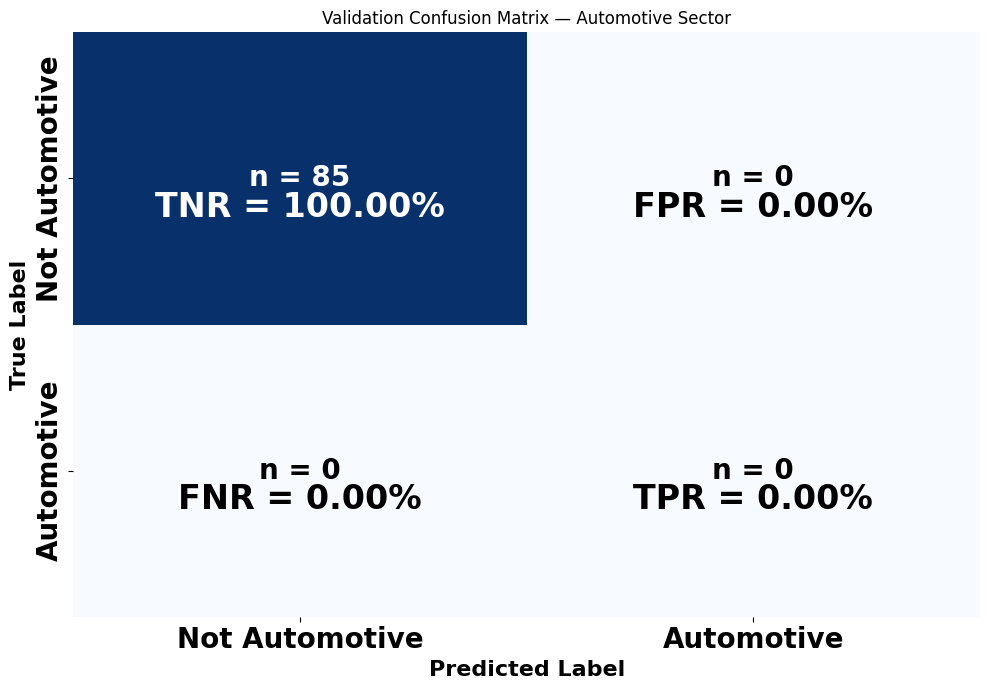


Validation — Sector: General Industrial
Accuracy: 0.9176
Classification Report:
              precision    recall  f1-score   support

           0       0.93      0.99      0.96        78
           1       0.50      0.14      0.22         7

    accuracy                           0.92        85
   macro avg       0.71      0.57      0.59        85
weighted avg       0.89      0.92      0.90        85

FP: 1, FN: 6
TPR: 0.14, FPR: 0.01, TNR: 0.99, FNR: 0.86


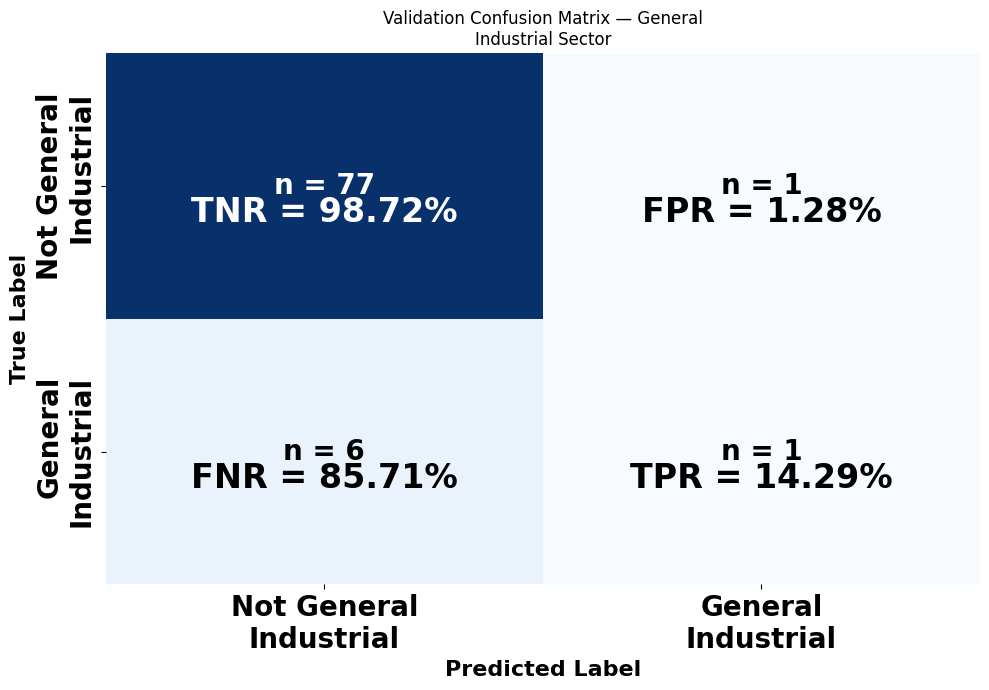


Validation — Sector: Architectural
Accuracy: 0.7294
Classification Report:
              precision    recall  f1-score   support

           0       0.92      0.77      0.84        77
           1       0.14      0.38      0.21         8

    accuracy                           0.73        85
   macro avg       0.53      0.57      0.52        85
weighted avg       0.85      0.73      0.78        85

FP: 18, FN: 5
TPR: 0.38, FPR: 0.23, TNR: 0.77, FNR: 0.62


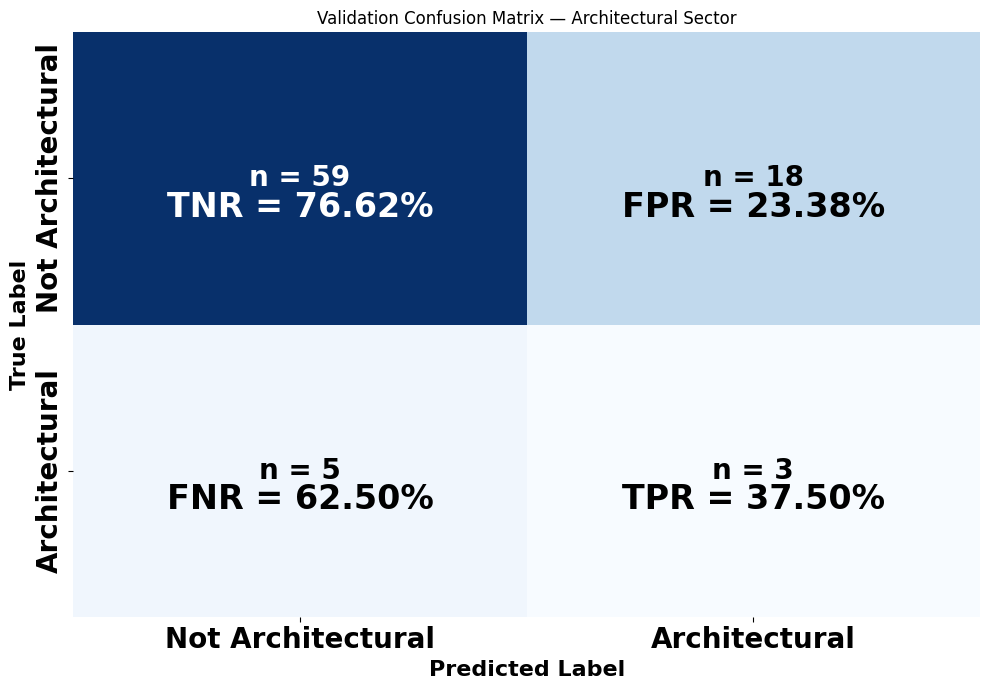


Validation — Sector: Road Marking
Accuracy: 0.5294
Classification Report:
              precision    recall  f1-score   support

           0       0.53      1.00      0.69        45
           1       0.00      0.00      0.00        40

    accuracy                           0.53        85
   macro avg       0.26      0.50      0.35        85
weighted avg       0.28      0.53      0.37        85

FP: 0, FN: 40
TPR: 0.00, FPR: 0.00, TNR: 1.00, FNR: 1.00


c:\flexgen\repos\projects\PLOPP-analysis\analysis\src\venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\flexgen\repos\projects\PLOPP-analysis\analysis\src\venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\flexgen\repos\projects\PLOPP-analysis\analysis\src\venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _

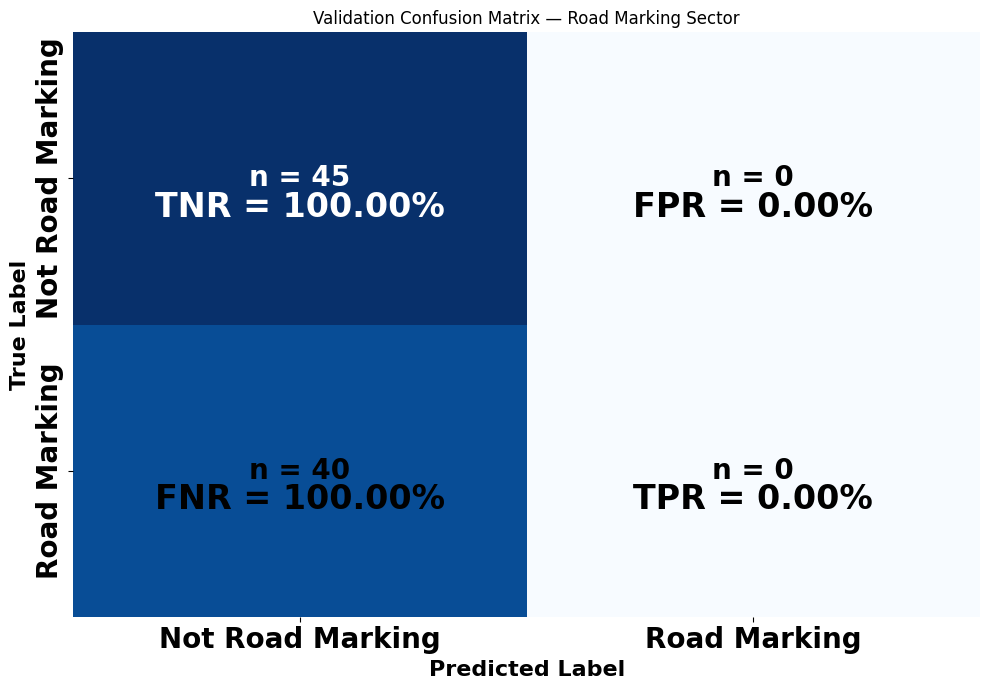


Validation — Sector: Consumer
Accuracy: 0.5882
Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.59      0.74        85
           1       0.00      0.00      0.00         0

    accuracy                           0.59        85
   macro avg       0.50      0.29      0.37        85
weighted avg       1.00      0.59      0.74        85

FP: 35, FN: 0
TPR: 0.00, FPR: 0.41, TNR: 0.59, FNR: 0.00


c:\flexgen\repos\projects\PLOPP-analysis\analysis\src\venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\flexgen\repos\projects\PLOPP-analysis\analysis\src\venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\flexgen\repos\projects\PLOPP-analysis\analysis\src\venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifi

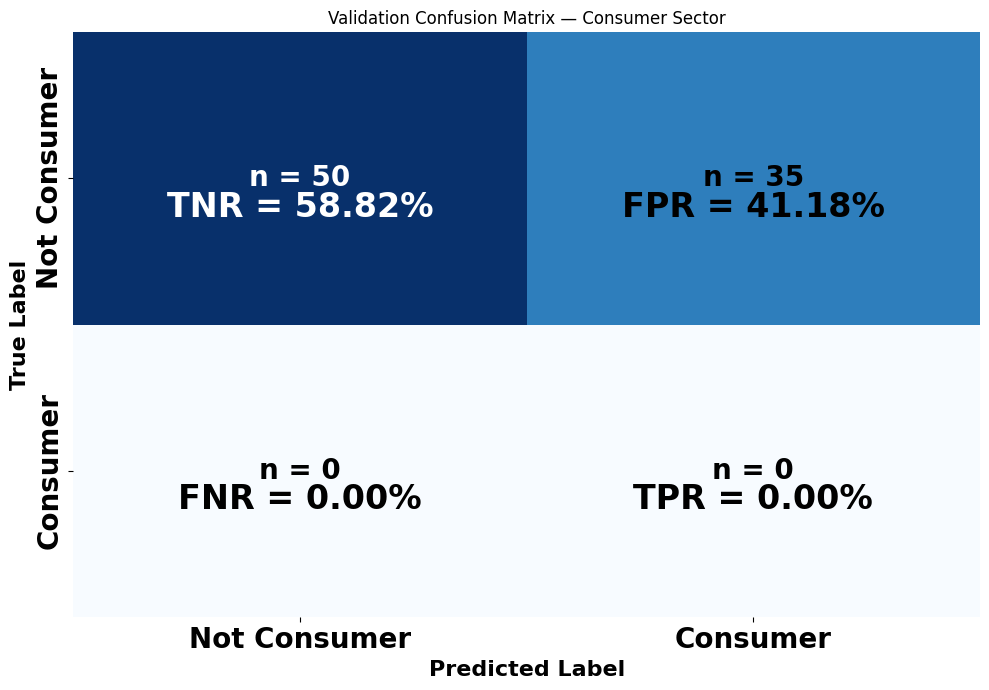


Validation — Sector: Wood
Accuracy: 0.9529
Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.96      0.98        84
           1       0.00      0.00      0.00         1

    accuracy                           0.95        85
   macro avg       0.49      0.48      0.49        85
weighted avg       0.98      0.95      0.96        85

FP: 3, FN: 1
TPR: 0.00, FPR: 0.04, TNR: 0.96, FNR: 1.00


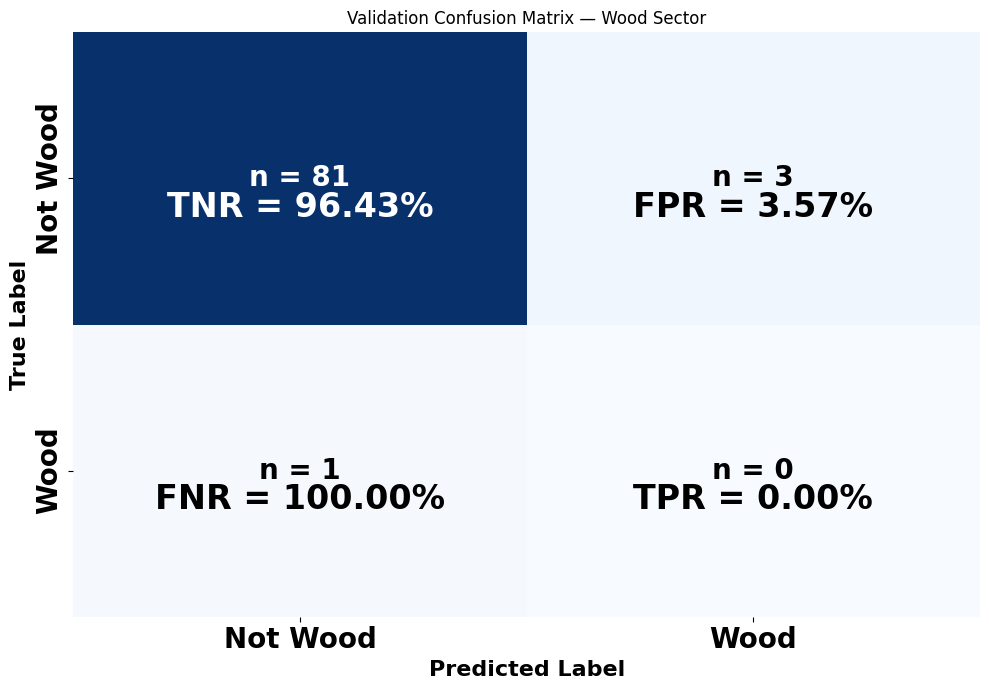


Validation — Sector: Marine
Accuracy: 0.3412
Classification Report:
              precision    recall  f1-score   support

           0       0.74      0.39      0.51        75
           1       0.00      0.00      0.00        10

    accuracy                           0.34        85
   macro avg       0.37      0.19      0.25        85
weighted avg       0.66      0.34      0.45        85

FP: 46, FN: 10
TPR: 0.00, FPR: 0.61, TNR: 0.39, FNR: 1.00


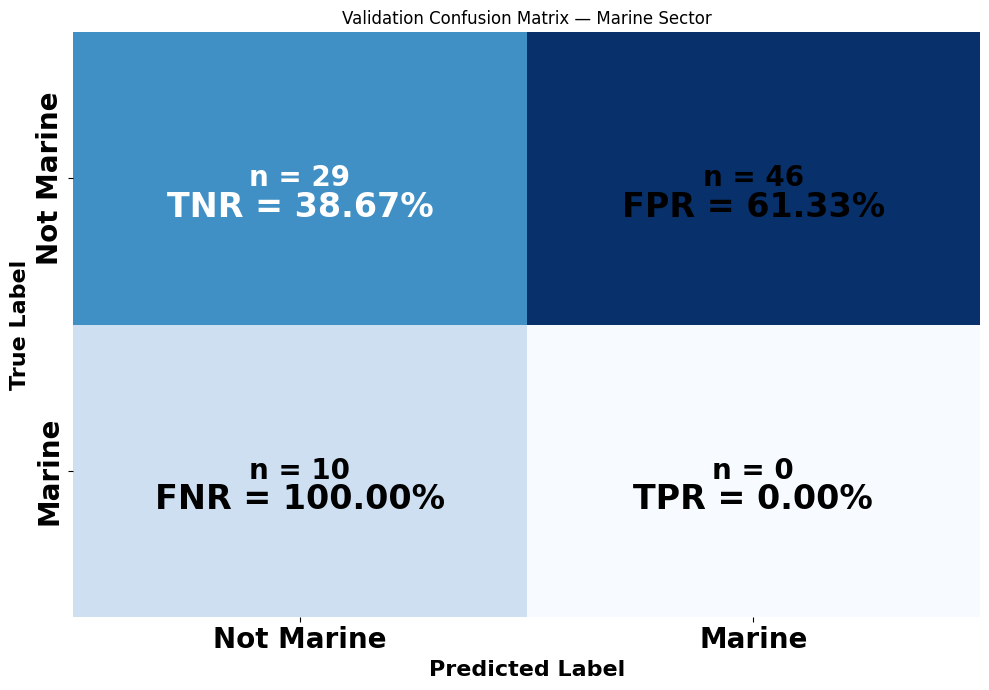

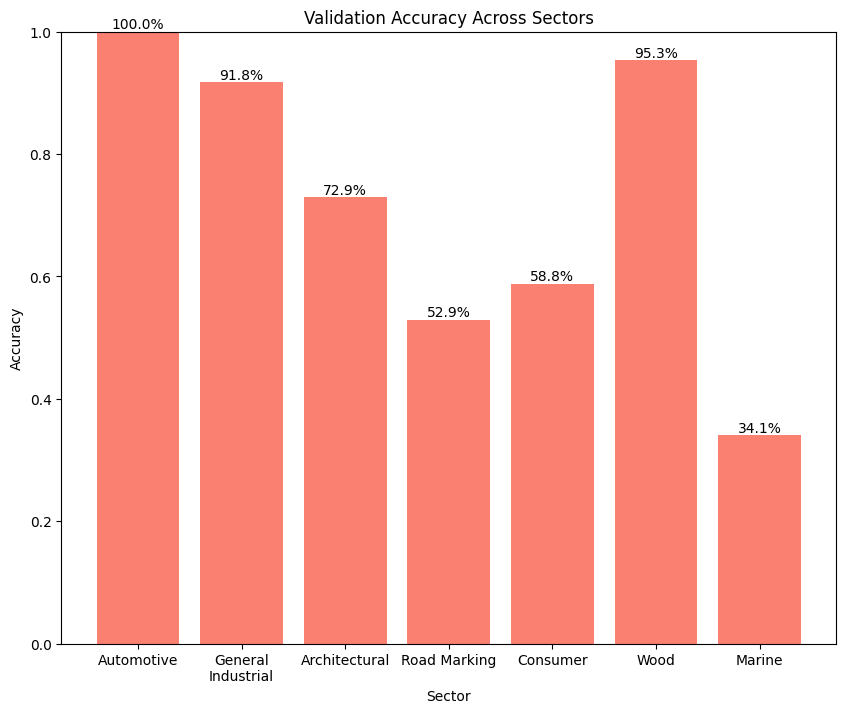


Mean Validation Accuracy: 0.7227


In [41]:
_val_drop_cols = ['Unnamed: 0', 'Sector', 'Target', 'Sample', 'Sample_x', 'Sample_y',
                  'Sample_Number', 'Color', 'CSVName', 'SectorBinary', 'prediction_group']

def validate_sector_model(pipeline, train_columns, val_data, target_sector):
    val_data = prepare_binary_labels(val_data, target_sector)

    X_val = val_data.drop(columns=_val_drop_cols, errors='ignore').select_dtypes(include='number')
    X_val.columns = X_val.columns.astype(str)
    X_val = X_val.reindex(columns=train_columns, fill_value=0)
    y_val = val_data['SectorBinary']

    y_pred = pipeline.predict(X_val)

    accuracy = accuracy_score(y_val, y_pred)
    print(f"\nValidation — Sector: {target_sector}")
    print(f"Accuracy: {accuracy:.4f}")
    print("Classification Report:")
    print(classification_report(y_val, y_pred))

    cm = confusion_matrix(y_val, y_pred, labels=[0, 1])
    tn, fp, fn, tp = cm.ravel()

    tpr = tp / (tp + fn) if (tp + fn) > 0 else 0
    fpr = fp / (fp + tn) if (fp + tn) > 0 else 0
    tnr = tn / (tn + fp) if (tn + fp) > 0 else 0
    fnr = fn / (fn + tp) if (fn + tp) > 0 else 0

    print(f'FP: {fp}, FN: {fn}')
    print(f'TPR: {tpr:.2f}, FPR: {fpr:.2f}, TNR: {tnr:.2f}, FNR: {fnr:.2f}')

    display_sector = target_sector.replace("General Industrial", "General\nIndustrial")
    not_display_sector = f"Not {target_sector}".replace("General Industrial", "General\nIndustrial")

    fig, ax = plt.subplots(figsize=(10, 7))
    sns.heatmap(cm, annot=False, fmt='d', cmap='Blues', cbar=False,
                xticklabels=[not_display_sector, display_sector],
                yticklabels=[not_display_sector, display_sector], ax=ax)
    ax.set_xlabel('Predicted Label', fontsize=16, weight='bold')
    ax.set_ylabel('True Label', fontsize=16, weight='bold')
    ax.set_xticklabels(ax.get_xticklabels(), fontsize=20, weight='bold')
    ax.set_yticklabels(ax.get_yticklabels(), fontsize=20, weight='bold')

    for i in range(2):
        for j in range(2):
            color = 'white' if (i == 0 and j == 0) else 'black'
            plt.text(j + 0.5, i + 0.5, f'n = {cm[i, j]}', ha='center', va='center', color=color, fontsize=20, weight='bold')

    plt.text(0.5, 0.6, f'TNR = {tnr * 100:.2f}%', ha='center', va='center', fontsize=24, weight='bold', color='white')
    plt.text(1.5, 0.6, f'FPR = {fpr * 100:.2f}%', ha='center', va='center', fontsize=24, weight='bold')
    plt.text(.5, 1.6, f'FNR = {fnr * 100:.2f}%', ha='center', va='center', fontsize=24, weight='bold')
    plt.text(1.5, 1.6, f'TPR = {tpr * 100:.2f}%', ha='center', va='center', fontsize=24, weight='bold', color='black')

    plt.title(f"Validation Confusion Matrix — {display_sector} Sector")
    plt.tight_layout()
    plt.show()

    return accuracy


# Run validation
val_accuracies = []

for sector in target_sectors:
    val_acc = validate_sector_model(trained_pipelines[sector], train_columns_by_sector[sector], total_merged.copy(), sector)
    val_accuracies.append(val_acc)

bar_labels = [l.replace('General Industrial', 'General\nIndustrial') for l in target_sectors]

plt.figure(figsize=(10, 9))
bars = plt.bar(bar_labels, val_accuracies, color='salmon')
plt.xlabel("Sector")
plt.ylabel("Accuracy")
plt.title("Validation Accuracy Across Sectors")
plt.xticks(rotation=0)
plt.ylim(0, 1)
plt.subplots_adjust(bottom=0.2)

for bar, acc in zip(bars, val_accuracies):
    plt.text(bar.get_x() + bar.get_width() / 2, bar.get_height(), f"{acc * 100:.1f}%",
             ha='center', va='bottom')

plt.show()
print(f"\nMean Validation Accuracy: {np.mean(val_accuracies):.4f}")